#### Imports

In [2]:
import numpy as np
import scipy.linalg as spla
from scipy.optimize import curve_fit
import NHimpurity_Suzy as NHI
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit
import importlib as imp
imp.reload(NHI)
from sklearn import linear_model

#### Parameters

0.0% of calculation completed.
0.0392156862745098% of calculation completed.
0.0784313725490196% of calculation completed.
0.1176470588235294% of calculation completed.
0.1568627450980392% of calculation completed.
0.19607843137254902% of calculation completed.
0.2352941176470588% of calculation completed.
0.27450980392156865% of calculation completed.
0.3137254901960784% of calculation completed.
0.35294117647058826% of calculation completed.
0.39215686274509803% of calculation completed.
0.4313725490196078% of calculation completed.
0.4705882352941176% of calculation completed.
4.509803921568627% of calculation completed.
4.549019607843137% of calculation completed.
4.588235294117647% of calculation completed.
4.627450980392156% of calculation completed.
4.666666666666667% of calculation completed.
4.705882352941177% of calculation completed.
4.745098039215686% of calculation completed.
4.784313725490196% of calculation completed.
4.823529411764706% of calculation completed.
4.862745

35.17647058823529% of calculation completed.
35.21568627450981% of calculation completed.
35.25490196078431% of calculation completed.
35.294117647058826% of calculation completed.
35.333333333333336% of calculation completed.
35.37254901960784% of calculation completed.
35.411764705882355% of calculation completed.
35.450980392156865% of calculation completed.
35.490196078431374% of calculation completed.
39.52941176470588% of calculation completed.
39.568627450980394% of calculation completed.
39.6078431372549% of calculation completed.
39.64705882352941% of calculation completed.
39.68627450980392% of calculation completed.
39.72549019607843% of calculation completed.
39.76470588235294% of calculation completed.
39.80392156862745% of calculation completed.
39.84313725490196% of calculation completed.
39.88235294117647% of calculation completed.
39.92156862745098% of calculation completed.
39.96078431372549% of calculation completed.
40.0% of calculation completed.
40.03921568627451%

74.50980392156863% of calculation completed.
74.54901960784314% of calculation completed.
74.58823529411764% of calculation completed.
74.62745098039215% of calculation completed.
74.66666666666667% of calculation completed.
74.70588235294117% of calculation completed.
74.74509803921569% of calculation completed.
74.7843137254902% of calculation completed.
74.82352941176471% of calculation completed.
74.86274509803921% of calculation completed.
74.90196078431373% of calculation completed.
74.94117647058823% of calculation completed.
74.98039215686273% of calculation completed.
75.01960784313727% of calculation completed.
75.05882352941177% of calculation completed.
75.09803921568627% of calculation completed.
75.13725490196079% of calculation completed.
75.17647058823529% of calculation completed.
75.2156862745098% of calculation completed.
75.25490196078431% of calculation completed.
75.29411764705883% of calculation completed.
75.33333333333333% of calculation completed.
75.372549019

ValueError: The number of FixedLocator locations (0), usually from a call to set_ticks, does not match the number of ticklabels (2).

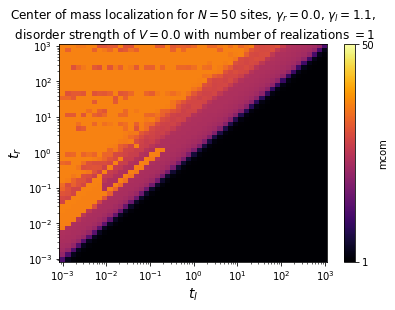

In [20]:

# Phase diagrams with realizations
# t_l vs t_r


N = 50
rl = 0.0
rr = 0.0

gam_r = 0.0
tr_array = 10**(np.linspace(-3,3,50))
gam_l = 1.1
tl_array = 10**(np.linspace(-3,3,51))
#V_array = [0.0, 0.1, 1.0, 5.0, 10.0]
V = 0.0
N_realizations = 1

com_array = np.zeros(shape=(len(tr_array), len(tl_array)))

for idx_tr, tr in enumerate(tr_array):
    for idx_tl, tl in enumerate(tl_array):
        realiz_avg = np.zeros(N)
        for realiz in range(N_realizations):
            onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
            Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                                  V_pot = onsite_pot,
                                                  tl = tl,
                                                  tr = tr,
                                                  gam_l = gam_l,
                                                  gam_r = gam_r,
                                                  rl = rl,
                                                  rr = rr)
            
            evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR = NHI.extract_spectrum(Ham)
           
            realiz_avg += abs_square_sum_r
        
        realiz_avg /= N_realizations
    
        com = 0
        for idx, i in enumerate(realiz_avg):
            com += i*idx
        com /= np.sum(realiz_avg)        
        com_array[idx_tr, idx_tl] = com
    
        percentage = (idx_tr*len(tl_array) + idx_tl)/(len(tl_array)*len(tr_array))*100
        if np.round(percentage,0)%5==0:
            print(f"{percentage}% of calculation completed.")



fig = plt.figure()#(figsize=(5,10))
ax = fig.add_subplot(111)

# Iterate over all values of V (one panel for each value):
X, Y = np.meshgrid(tl_array, tr_array)   
    
heatmap = ax.pcolormesh(X, Y, com_array, vmin = 1, vmax = N, cmap="inferno", shading="auto")
                 
ax.set_xlabel(r"$t_l$", fontsize = 14)
ax.set_ylabel(r"$t_r$", fontsize = 14)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(r"Center of mass localization for $N=$%s sites, $\gamma_r =$%s, $\gamma_l =$%s,"%(N, gam_r, gam_l)+"\n"+r" disorder strength of $V =$%s with number of realizations $= $%s"%(V, N_realizations))
cbar = plt.colorbar(heatmap, ticks = [1, N], label= "mcom") #, location = "top", orientation = "horizontal")
cbar.ax.set_xticklabels([r"$1$", r"$N$"])    
plt.tight_layout()
plt.show()



9.96078431372549% of calculation completed.
19.96078431372549% of calculation completed.
29.96078431372549% of calculation completed.
39.96078431372549% of calculation completed.
49.96078431372549% of calculation completed.
59.96078431372549% of calculation completed.
69.96078431372548% of calculation completed.
79.96078431372548% of calculation completed.
89.9607843137255% of calculation completed.
99.9607843137255% of calculation completed.


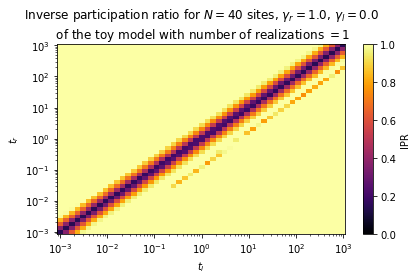

In [17]:

##################################################################################
###################################### IPR #######################################
################################### t_r vs t_l ###################################
##################################################################################
# 

N = 40
rl = 0.0
rr = 0.0

gam_r = 1.0
gam_l = 0.0
tr_array = 10**(np.linspace(-3,3,50))
tl_array = 10**(np.linspace(-3,3,51))
#V_array = [0.0, 0.1] #, 1.0, 5.0, 10.0]
V = 0.0
N_realizations = 1
#V_avg = np.sum(V_array)/len(V_array)

fig = plt.figure() #figsize=(2,20))
X, Y = np.meshgrid(tl_array, tr_array)

IPR_array = np.zeros(shape=(len(tr_array), len(tl_array))) #, len(V_array)))
#disorder_avg_list = []
#disorder_avg = np.zeros(N)
for idx_tr, tr in enumerate(tr_array):
    for idx_tl, tl in enumerate(tl_array):
        IPR = 0.0
        SUM = 0.0
        for realiz in range(N_realizations):
            # onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)
            # onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
            Ham = NHI.Hatano_Nelson_Ham(N = N,
                                        tl = tl,
                                        tr = tr,
                                        gam_l = gam_l,
                                        gam_r = gam_r,
                                        rl = rl,
                                        rr = rr)
                                                
#             Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
#                                                 V_pot = onsite_pot,
#                                                 tl = tl,
#                                                 tr = tr,
#                                                 gam_l = gam_l,
#                                                 gam_r = gam_r,
#                                                 rl = rl,
#                                                 rr = rr)
            
            evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR = NHI.extract_spectrum(Ham)
            
            # Calculate IPR for this realization
            
            for k in range(N):
                for n in range(N):
                    SUM += np.abs(REvecs[k,n])**4
            IPR += SUM / N
        # Average over realizations
        IPR_array[idx_tr, idx_tl] = IPR/N_realizations 
        
            #disorder_avg += abs_square_sum_r/N_realizations 
                
    percentage = (idx_tr*len(tl_array) + idx_tl)/(len(tl_array)*len(tr_array))*100
    if np.round(percentage,0)%5==0:
        print(f"{percentage}% of calculation completed.")
    
    # percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
    # if np.round(10000*percentage,0)%500==0:
    #         print(f"{percentage}% of calculation completed.")



#fig = plt.figure(figsize=(6,20))
# ax = fig.add_subplot(111)

# Iterate over all values of V (one panel for each value):
#X, Y = np.meshgrid(gam_r_array, tr_array)   

#for idx_V, V in enumerate(V_array):
#ax_value = len(V_array)*100 + 10 + idx_V + 1
ax = fig.add_subplot(111)
heatmap = ax.pcolormesh(X, Y, IPR_array[:, :], vmin = 0, vmax = 1, cmap="inferno", shading="auto")
                 
ax.set_xlabel(r"$t_l$")
ax.set_ylabel(r"$t_r$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(r"Inverse participation ratio for $N=$%s sites, $\gamma_r =$%s, $\gamma_l =$%s"%(N, gam_r, gam_l)+"\n"+r" of the toy model with number of realizations $=$%s"%(N_realizations))
cbar = plt.colorbar(heatmap, label= "IPR")#, location = "top", orientation = "horizontal")
#cbar.ax.set_yticklabels([r"$1$", r"$1$"])  

plt.tight_layout()
plt.show()



In [2]:
N = 40   # Must be even integer.
tl = 1   # FIXED as unit of energy, left hoppings
tr = 1   # FIXED as unit of energy, right hoppings
rl = 0.0 # Open boundaries, i.e. left boundary hopping value
rr = 0.0 # right boundary hopping value
gam_l = 0.9 # Impurity in the middle of the sequence, left hopping
gam_r = 1.1 # Impurity in the middle of the sequence, right hopping

#### Utilities

In [3]:
# extract a discretized set of colors from the rainbow
colors = plt.cm.rainbow(np.linspace(0,1,N))
colorlist = ['fuchsia', 'purple', 'mediumblue',  'lightskyblue', 'aqua', 'yellow', 'green', 'yellowgreen', 'gold', 'orange', 'peru', 'red', 'brown' ]

#### Construct the Hamiltonian and diagonalize it

In [5]:
Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                            tr = tr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            rl = rl,
                            rr = rr,
                            N = N)

Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR  = NHI.extract_spectrum(Ham)

# test to see if the evecs are normalized:
print(spla.norm(REvecs[:,0]))

# Check Hamiltonian shape:
Hamtest = NHI.Hatano_Nelson_Ham(tl = 1.0, tr = 2.0, gam_l = 3, gam_r = 4, rl = 0.0, rr = 0.0, N = 6) # N: Even integer.
print(Hamtest)

1.0000000000000002
[[0. 1. 0. 0. 0. 0.]
 [2. 0. 1. 0. 0. 0.]
 [0. 2. 0. 3. 0. 0.]
 [0. 0. 4. 0. 1. 0.]
 [0. 0. 0. 2. 0. 1.]
 [0. 0. 0. 0. 2. 0.]]


#### Plotting the eigenspectrum

Normalized eigenvectors? 0.9999999999999999


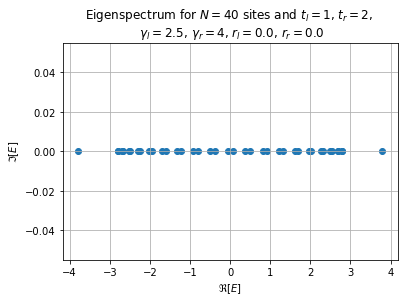

In [7]:
N = 40
tl = 1   
tr = 2    
gam_l = 2.5 
gam_r = 4
rl = 0.0 
rr = 0.0

Ham = NHI.Hatano_Nelson_Ham(N = N,
                            tl = tl,
                            tr = tr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            rl = rl,
                            rr = rr)
Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR  = NHI.extract_spectrum(Ham)


# test to see if the evecs are normalized:
print("Normalized eigenvectors?", spla.norm(REvecs[:,0]))

fig = plt.figure()
ax1 = fig.add_subplot(111) ##adding first(3:e ettan) subplot in layout that has 1 row and 1 column.########Remove later#######
ax1.scatter(Evals_real, Evals_imag) 
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr))
plt.grid()
#plt.tight_layout()
plt.show()  

#### Plotting the eigenvectors

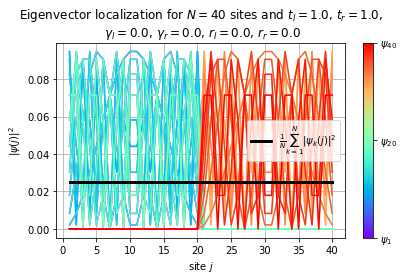

In [9]:
# Plotting eigenvectors
N = 40 
tl = 1.0   
tr = 1.0
gam_l = 0.0 
gam_r = 0.0 
colors = plt.cm.rainbow(np.linspace(0,1,N))


Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                            tr = tr,
                            rl = rl,
                            rr = rr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            N = N)

Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR = NHI.extract_spectrum(Ham)

fig = plt.figure()
ax2 = fig.add_subplot(111)
site_array = np.linspace(1,N,N) 

# Iterate over all right eigenvectors:
for i in range(N):
    ax2.plot(site_array, np.abs(REvecs[:,i])**2, color=colors[i])
    
ax2.plot(site_array, abs_square_sum_r/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax2.set_xlabel(r"site $j$")
ax2.set_ylabel(r"$|\psi(j)|^2$")
ax2.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s,""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax2, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show() 


##############################################################################################################################


#### Plotting the scaling behavior

%0.0 of eigenspectrum calculation completed.
%16.666666666666664 of eigenspectrum calculation completed.
%33.33333333333333 of eigenspectrum calculation completed.
%50.0 of eigenspectrum calculation completed.
%66.66666666666666 of eigenspectrum calculation completed.
%83.33333333333334 of eigenspectrum calculation completed.


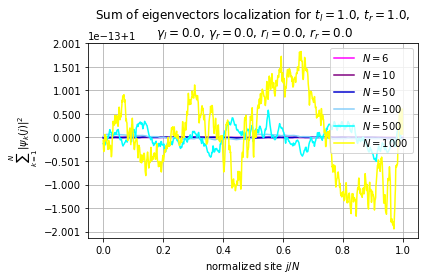

In [10]:
N_array = [6, 10, 50, 100, 500, 1000]

fig = plt.figure()
ax3 = fig.add_subplot(111)

# Iterate over all eigenvectors:
for idx, N in enumerate(N_array):
    site_array = np.linspace(0,N,N)
    Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                tr = tr,
                                gam_l = gam_l,
                                gam_r = gam_r,
                                rl = rl,
                                rr = rr,
                                N = N)
    print(f"%{idx/len(N_array)*100} of eigenspectrum calculation completed.")

    abs_square_sum_r = NHI.extract_spectrum(Ham)[5]
    ax3.plot(site_array/N, abs_square_sum_r, color=colorlist[idx], label=r"$N=$%s"%(N))
    
ax3.set_xlabel(r"normalized site $j/N$")
ax3.set_ylabel(r"$\sum_{k=1}^N |\psi_k(j)|^2$")
ax3.set_title(r"Sum of eigenvectors localization for $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(tl, tr, gam_l, gam_r, rl, rr))
plt.legend(loc='best')
plt.tight_layout()
plt.grid()
plt.show()

%0.0 of eigenspectrum calculation completed.
%16.666666666666664 of eigenspectrum calculation completed.
%33.33333333333333 of eigenspectrum calculation completed.
%50.0 of eigenspectrum calculation completed.
%66.66666666666666 of eigenspectrum calculation completed.
%83.33333333333334 of eigenspectrum calculation completed.


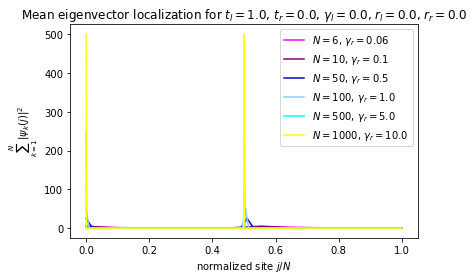

%0.0 of eigenspectrum calculation completed.
%16.666666666666664 of eigenspectrum calculation completed.
%33.33333333333333 of eigenspectrum calculation completed.
%50.0 of eigenspectrum calculation completed.
%66.66666666666666 of eigenspectrum calculation completed.
%83.33333333333334 of eigenspectrum calculation completed.


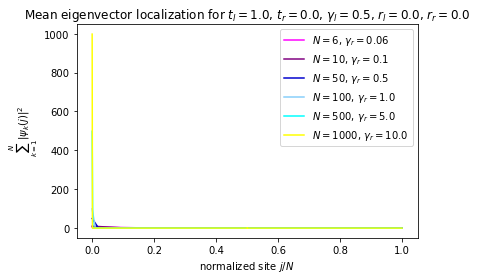

%0.0 of eigenspectrum calculation completed.
%16.666666666666664 of eigenspectrum calculation completed.
%33.33333333333333 of eigenspectrum calculation completed.
%50.0 of eigenspectrum calculation completed.
%66.66666666666666 of eigenspectrum calculation completed.
%83.33333333333334 of eigenspectrum calculation completed.


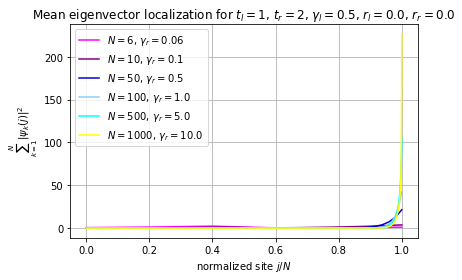

In [11]:
N_array = [6, 10, 50, 100, 500, 1000]
tl = 1.0
tr = 0.0
fig = plt.figure()
ax3 = fig.add_subplot(111)
alpha=0.01
gam_l = 0.0

# Iterate over all eigenvectors:
for idx, N in enumerate(N_array):
    site_array = np.linspace(0,N,N)  
    Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                tr = tr,
                                gam_l = gam_l,
                                gam_r = alpha * N,
                                rl = rl,
                                rr = rr,
                                N = N)
    print(f"%{idx/len(N_array)*100} of eigenspectrum calculation completed.")

    abs_square_sum_r = NHI.extract_spectrum(Ham)[5]
    ax3.plot(site_array/N, abs_square_sum_r, color=colorlist[idx], label=r"$N=$%s, $\gamma_r=$%s"%(N, alpha*N))
    
ax3.set_xlabel(r"normalized site $j/N$")
ax3.set_ylabel(r"$\sum_{k=1}^N |\psi_k(j)|^2$")
ax3.set_title(r"Mean eigenvector localization for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(tl, tr, gam_l, rl, rr))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

fig = plt.figure()
ax4 = fig.add_subplot(111)
gam_l = 0.5
# Iterate over all eigenvectors:
for idx, N in enumerate(N_array):
    site_array = np.linspace(0,N,N)  
    Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                tr = tr,
                                gam_l = gam_l,
                                gam_r = alpha * N,
                                rl = rl,
                                rr = rr,
                                N = N)
    print(f"%{idx/len(N_array)*100} of eigenspectrum calculation completed.")

    abs_square_sum_r = NHI.extract_spectrum(Ham)[5]
    ax4.plot(site_array/N, abs_square_sum_r, color=colorlist[idx], label=r"$N=$%s, $\gamma_r=$%s"%(N, alpha*N))
    
ax4.set_xlabel(r"normalized site $j/N$")
ax4.set_ylabel(r"$\sum_{k=1}^N |\psi_k(j)|^2$")
ax4.set_title(r"Mean eigenvector localization for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(tl, tr, gam_l, rl, rr))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

###############################################################################################################################
# NH bulk

fig = plt.figure()
ax4 = fig.add_subplot(111)
gam_l = 0.5
tl = 1
tr = 2
# Iterate over all eigenvectors:
for idx, N in enumerate(N_array):
    site_array = np.linspace(0,N,N)  
    Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                tr = tr,
                                gam_l = gam_l,
                                gam_r = alpha * N,
                                rl = rl,
                                rr = rr,
                                N = N)
    print(f"%{idx/len(N_array)*100} of eigenspectrum calculation completed.")

    abs_square_sum_r = NHI.extract_spectrum(Ham)[5]
    ax4.plot(site_array/N, abs_square_sum_r, color=colorlist[idx], label=r"$N=$%s, $\gamma_r=$%s"%(N, alpha*N))
    
ax4.set_xlabel(r"normalized site $j/N$")
ax4.set_ylabel(r"$\sum_{k=1}^N |\psi_k(j)|^2$")
ax4.set_title(r"Mean eigenvector localization for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(tl, tr, gam_l, rl, rr))
plt.legend(loc='best')
plt.tight_layout()
plt.grid()
plt.show()

#### Only increasing hopping in the bulk to the left

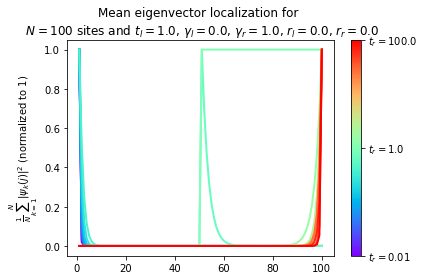

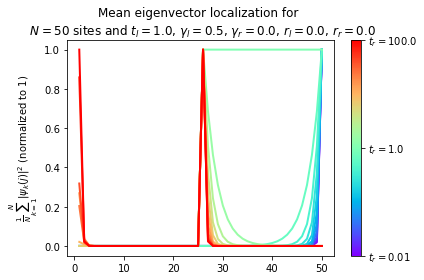

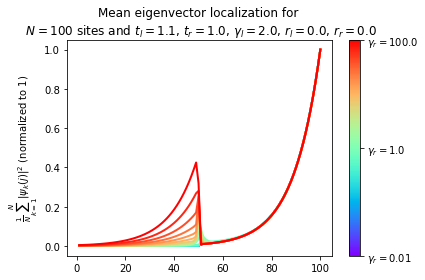

In [18]:
N = 100
tl = 1.0  # FIXED as unit of energy
gam_l = 0.0
gam_r = 1.0
rl = 0.0
rr = 0.0

tr_array = 10**(np.linspace(-2.0, 2.0, 21))
site_array = np.linspace(1,N,N) 
colors = plt.cm.rainbow(np.linspace(0,1,len(tr_array)))

ass_list = []
for idx, i in enumerate(tr_array):
    Ham = NHI.Hatano_Nelson_Ham(tl = tl, tr = i, gam_l = gam_l, gam_r = gam_r, rl = rl, rr = rr, N = N)
    ass = NHI.extract_spectrum(Ham)[5]
    ass_list.append(ass/np.amax(ass))
    #if idx%50==0:
        #print(f"%{idx/len(tl_array)*100} of eigenspectrum calculation completed.")

# Plotting
fig = plt.figure() #(figsize=(8,6))
ax5 = fig.add_subplot(111)
for idx, i in enumerate(tr_array):
    ax5.plot(site_array, ass_list[idx], color=colors[idx], lw=2)    
ax5.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$ (normalized to 1)")
#ax5.set_xlim([1,10])
ax5.set_title(r"Mean eigenvector localization for ""\n"" $N=$%s sites and $t_l=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax5, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$t_r=$%s"%(tr_array[0]), r"$t_r=$%s"%(tr_array[int(len(tr_array)/2)]), r"$t_r=$%s"%(tr_array[-1])])
plt.tight_layout()
plt.show()

##############################################################################################################################

N = 50
tl = 1.0  # FIXED as unit of energy
gam_l = 0.5
gam_r = 0.0
rl = 0.0
rr = 0.0

tr_array = 10**(np.linspace(-2.0, 2.0, 21))
site_array = np.linspace(1,N,N) 
colors = plt.cm.rainbow(np.linspace(0,1,len(tr_array)))

ass_list = []
for idx, i in enumerate(tr_array):
    Ham = NHI.Hatano_Nelson_Ham(tl = tl, tr = i, gam_l = gam_l, gam_r = gam_r, rl = rl, rr = rr, N = N)
    ass = NHI.extract_spectrum(Ham)[4]
    ass_list.append(ass/np.amax(ass))
    #if idx%50==0:
        #print(f"%{idx/len(tl_array)*100} of eigenspectrum calculation completed.")

# Plotting
fig = plt.figure() #(figsize=(8,6))
ax5 = fig.add_subplot(111)
for idx, i in enumerate(tr_array):
    ax5.plot(site_array, ass_list[idx], color=colors[idx], lw=2)    
ax5.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$ (normalized to 1)")
#ax5.set_xlim([1,10])
ax5.set_title(r"Mean eigenvector localization for ""\n"" $N=$%s sites and $t_l=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax5, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$t_r=$%s"%(tr_array[0]), r"$t_r=$%s"%(tr_array[int(len(tr_array)/2)]), r"$t_r=$%s"%(tr_array[-1])])
plt.tight_layout()
plt.show()

################################################################################################################################

N = 100
tl = 1.1  # FIXED as unit of energy
tr = 1.0
gam_l = 2.0
gam_r = 4.0
rl = 0.0
rr = 0.0

gam_r_array = 10**(np.linspace(-2.0, 2.0, 21))
site_array = np.linspace(1,N,N) 
colors = plt.cm.rainbow(np.linspace(0,1,len(gam_r_array)))

ass_list = []
for idx, i in enumerate(gam_r_array):
    Ham = NHI.Hatano_Nelson_Ham(tl = tl, tr = tr, gam_l = gam_l, gam_r = i, rl = rl, rr = rr, N = N)
    ass = NHI.extract_spectrum(Ham)[4]
    ass_list.append(ass/np.amax(ass))
    #if idx%50==0:
        #print(f"%{idx/len(tl_array)*100} of eigenspectrum calculation completed.")

# Plotting
fig = plt.figure() #(figsize=(8,6))
ax5 = fig.add_subplot(111)
for idx, i in enumerate(gam_r_array):
    ax5.plot(site_array, ass_list[idx], color=colors[idx], lw=2)    
ax5.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$ (normalized to 1)")
#ax5.set_xlim([1,10])
ax5.set_title(r"Mean eigenvector localization for ""\n"" $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax5, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\gamma_r=$%s"%(gam_r_array[0]), r"$\gamma_r=$%s"%(gam_r_array[int(len(gam_r_array)/2)]), r"$\gamma_r=$%s"%(gam_r_array[-1])])
plt.tight_layout()
plt.show()



%0.0 of eigenspectrum calculation completed.
%16.666666666666664 of eigenspectrum calculation completed.
%33.33333333333333 of eigenspectrum calculation completed.
%50.0 of eigenspectrum calculation completed.
%66.66666666666666 of eigenspectrum calculation completed.
%83.33333333333334 of eigenspectrum calculation completed.


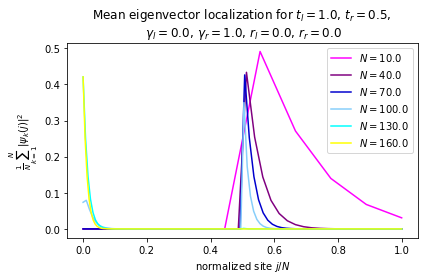

In [23]:
N_array = np.linspace(10, 160, 6)
fig = plt.figure()
ax3 = fig.add_subplot(111)
#alpha=0.01
tl = 1.0
tr = 0.5
gam_l = 0.0
gam_r = 1.0

# Iterate over all eigenvectors:
for idx, N in enumerate(N_array):
    site_array = np.linspace(0,int(N),int(N))  
    Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                tr = tr,
                                gam_l = gam_l,
                                gam_r = gam_r,
                                rl = rl,
                                rr = rr,
                                N = int(N))
    print(f"%{idx/len(N_array)*100} of eigenspectrum calculation completed.")

    abs_square_sum_r = NHI.extract_spectrum(Ham)[4]
    ax3.plot(site_array/N, abs_square_sum_r/N, color=colorlist[idx], label=r"$N=$%s"%(N))
    
ax3.set_xlabel(r"normalized site $j/N$")
ax3.set_ylabel(r"$\frac{1}{N}\sum_{k=1}^N |\psi_k(j)|^2$")
ax3.set_title(r"Mean eigenvector localization for $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(tl, tr, gam_l, gam_r, rl, rr))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

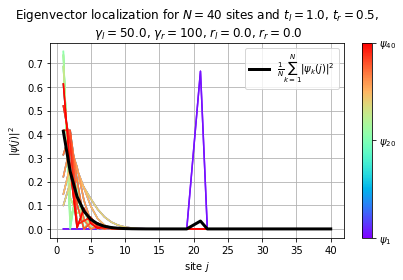

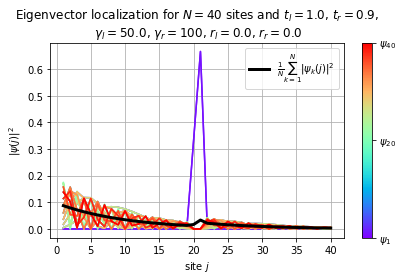

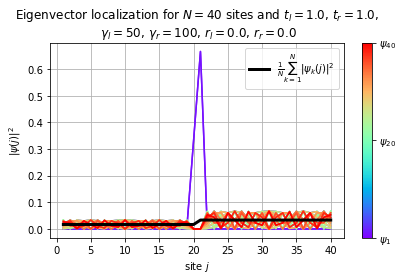

In [24]:
# Plotting eigenvectors
N = 40 
tl = 1.0   
tr = 0.5
gam_l = 50.0 
gam_r = 100 
colors = plt.cm.rainbow(np.linspace(0,1,N))


Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                            tr = tr,
                            rl = rl,
                            rr = rr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            N = N)

Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)

fig = plt.figure()
ax2 = fig.add_subplot(111)
site_array = np.linspace(1,N,N) 

# Iterate over all right eigenvectors:
for i in range(N):
    ax2.plot(site_array, np.abs(REvecs[:,i])**2, color=colors[i])
    
ax2.plot(site_array, abs_square_sum_r/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax2.set_xlabel(r"site $j$")
ax2.set_ylabel(r"$|\psi(j)|^2$")
ax2.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s,""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax2, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show() 

###############################################################################################################################

# Plotting eigenvectors
N = 40 
tl = 1.0   
tr = 0.9
gam_l = 50.0 
gam_r = 100 
colors = plt.cm.rainbow(np.linspace(0,1,N))


Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                            tr = tr,
                            rl = rl,
                            rr = rr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            N = N)

Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)

fig = plt.figure()
ax2 = fig.add_subplot(111)
site_array = np.linspace(1,N,N) 

# Iterate over all right eigenvectors:
for i in range(N):
    ax2.plot(site_array, np.abs(REvecs[:,i])**2, color=colors[i])
    
ax2.plot(site_array, abs_square_sum_r/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax2.set_xlabel(r"site $j$")
ax2.set_ylabel(r"$|\psi(j)|^2$")
ax2.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s,""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax2, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show() 

###############################################################################################################################

# Plotting eigenvectors
N = 40 
tl = 1.0   
tr = 1.0
gam_l = 50 
gam_r = 100 
colors = plt.cm.rainbow(np.linspace(0,1,N))


Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                            tr = tr,
                            rl = rl,
                            rr = rr,
                            gam_l = gam_l,
                            gam_r = gam_r,
                            N = N)

Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)

fig = plt.figure()
ax2 = fig.add_subplot(111)
site_array = np.linspace(1,N,N) 

# Iterate over all right eigenvectors:
for i in range(N):
    ax2.plot(site_array, np.abs(REvecs[:,i])**2, color=colors[i])
    
ax2.plot(site_array, abs_square_sum_r/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax2.set_xlabel(r"site $j$")
ax2.set_ylabel(r"$|\psi(j)|^2$")
ax2.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s,""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax2, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show() 

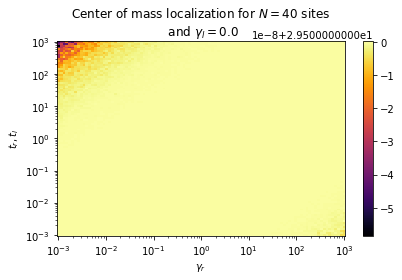

In [25]:
N = 40
tl = 0.0    # FIXED as unit of energy
gam_l = 0.0
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tr, #Hermitian
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        #percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        #if np.round(10000*percentage,0)%500==0:
            #print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r, t_l$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites ""\n"" and $\gamma_l=$%s"%(N, gam_l))
cbar = plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

## Phase diagram, no disorder

0.0% of calculation completed.
1.0% of calculation completed.
2.0% of calculation completed.
3.0% of calculation completed.
4.0% of calculation completed.
5.0% of calculation completed.
6.0% of calculation completed.
7.000000000000001% of calculation completed.
8.0% of calculation completed.
9.0% of calculation completed.
10.0% of calculation completed.
11.0% of calculation completed.
12.0% of calculation completed.
13.0% of calculation completed.
14.000000000000002% of calculation completed.
15.0% of calculation completed.
16.0% of calculation completed.
17.0% of calculation completed.
18.0% of calculation completed.
19.0% of calculation completed.
20.0% of calculation completed.
21.0% of calculation completed.
22.0% of calculation completed.
23.0% of calculation completed.
24.0% of calculation completed.
25.0% of calculation completed.
26.0% of calculation completed.
27.0% of calculation completed.
28.000000000000004% of calculation completed.
28.999999999999996% of calculation compl

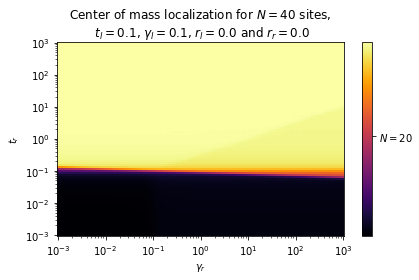

In [26]:
#Phase diagrams

N = 40
tl = 0.1   # FIXED as unit of energy
gam_l = 0.1
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        if np.round(10000*percentage,0)%500==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites, ""\n"" $t_l=$%s, $\gamma_l=$%s, $r_l=$%s and $r_r=$%s"%(N, tl, gam_l, rl, rr))
cbar = plt.colorbar(heatmap, ax=ax7, ticks = [0, N/2, N])
cbar.ax.set_yticklabels([r"$N = 0$", r"$N = {%s}$"%(int(N/2)), r"$N = {%s}$"%(int(N))])
plt.tight_layout()
plt.show()

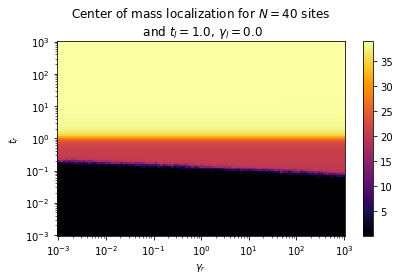

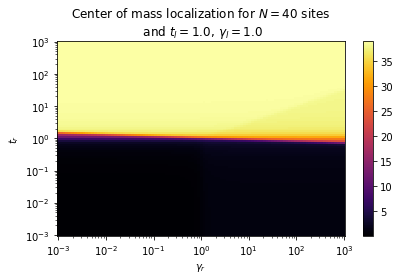

In [27]:
N = 40
tl = 1.0    # FIXED as unit of energy
gam_l = 0.0
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        #percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        #if np.round(10000*percentage,0)%500==0:
            #print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites ""\n"" and $t_l=$%s, $\gamma_l=$%s"%(N, tl, gam_l))
cbar = plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

##########################################################################################################################

N = 40
tl = 1.0    # FIXED as unit of energy
gam_l = 1.0
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        #percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        #if np.round(10000*percentage,0)%500==0:
            #print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites ""\n"" and $t_l=$%s, $\gamma_l=$%s"%(N, tl, gam_l))
cbar = plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

0.0% of calculation completed.
1.0% of calculation completed.
2.0% of calculation completed.
3.0% of calculation completed.
4.0% of calculation completed.
5.0% of calculation completed.
6.0% of calculation completed.
7.000000000000001% of calculation completed.
8.0% of calculation completed.
9.0% of calculation completed.
10.0% of calculation completed.
11.0% of calculation completed.
12.0% of calculation completed.
13.0% of calculation completed.
14.000000000000002% of calculation completed.
15.0% of calculation completed.
16.0% of calculation completed.
17.0% of calculation completed.
18.0% of calculation completed.
19.0% of calculation completed.
20.0% of calculation completed.
21.0% of calculation completed.
22.0% of calculation completed.
23.0% of calculation completed.
24.0% of calculation completed.
25.0% of calculation completed.
26.0% of calculation completed.
27.0% of calculation completed.
28.000000000000004% of calculation completed.
28.999999999999996% of calculation compl

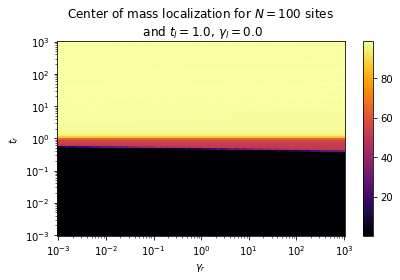

0.0% of calculation completed.
1.0% of calculation completed.
2.0% of calculation completed.
3.0% of calculation completed.
4.0% of calculation completed.
5.0% of calculation completed.
6.0% of calculation completed.
7.000000000000001% of calculation completed.
8.0% of calculation completed.
9.0% of calculation completed.
10.0% of calculation completed.
11.0% of calculation completed.
12.0% of calculation completed.
13.0% of calculation completed.
14.000000000000002% of calculation completed.
15.0% of calculation completed.
16.0% of calculation completed.
17.0% of calculation completed.
18.0% of calculation completed.
19.0% of calculation completed.
20.0% of calculation completed.
21.0% of calculation completed.
22.0% of calculation completed.
23.0% of calculation completed.
24.0% of calculation completed.
25.0% of calculation completed.
26.0% of calculation completed.
27.0% of calculation completed.
28.000000000000004% of calculation completed.
28.999999999999996% of calculation compl

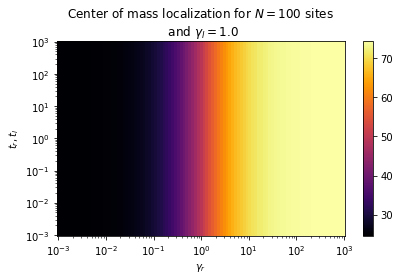

In [28]:
N = 100
tl = 1.0    # FIXED as unit of energy
gam_l = 0.0
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tl,
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        if np.round(10000*percentage,0)%500==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites ""\n"" and $t_l=$%s, $\gamma_l=$%s"%(N, tl, gam_l))
cbar = plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

##########################################################################################################################

N = 100
tl = 0.0    # FIXED as unit of energy
gam_l = 1.0
tr_array = 10**(np.linspace(-3, 3, 100)) # 100 tr values ranging -3 to 3
gam_r_array = 10**(np.linspace(-3, 3, 101)) #101 gam_r values


com_array = np.zeros(shape=(len(tr_array), len(gam_r_array)))
for idx_tr, tr in enumerate(tr_array):
    for idx_gam_r, gam_r in enumerate(gam_r_array):
                             
        Ham = NHI.Hatano_Nelson_Ham(tl = tr, #Hermitian
                                    tr = tr,
                                    gam_l = gam_l,
                                    gam_r = gam_r,
                                    rl = rl,
                                    rr = rr,
                                    N = N)

        evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
        
        #print(abs_square_sum)
        com = 0
        for idx, i in enumerate(abs_square_sum_r):
            com += i*idx
        com /= np.sum(abs_square_sum_r)        
        com_array[idx_tr, idx_gam_r] = com
        
        percentage = (idx_tr*len(gam_r_array) + idx_gam_r )/(len(gam_r_array)*len(tr_array))*100
        if np.round(10000*percentage,0)%500==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure()
ax7 = fig.add_subplot(111)

X, Y = np.meshgrid(gam_r_array, tr_array)
heatmap = ax7.pcolormesh(X, Y, com_array, cmap="inferno", shading = "auto")
ax7.set_xlabel(r"$\gamma_r$")
ax7.set_ylabel(r"$t_r, t_l$")
ax7.set_xscale("log")
ax7.set_yscale("log")
ax7.set_title(r"Center of mass localization for $N=$%s sites ""\n"" and $\gamma_l=$%s"%(N, gam_l))
cbar = plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

# Hatano Nelson plus on-site alternating potential

In [12]:
import numpy as np
import scipy.linalg as spla
from scipy.optimize import curve_fit
import NHimpurity_Suzy as NHI
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit
import importlib as imp
imp.reload(NHI)
from sklearn import linear_model

#### Parameters and utilities

In [13]:
# extract a discretized set of colors from the rainbow
colors = plt.cm.rainbow(np.linspace(0,1,N))
colorlist = ['fuchsia', 'purple', 'mediumblue',  'lightskyblue', 'aqua', 'mediumspringgreen', 'green', 'yellowgreen', 'gold', 'orange', 'peru', 'red', 'brown' ]

#### Construct the Hamiltonian and diagonalize it

In [14]:
N = 40
V = 2
tl = 1
tr = 1
gam_l = 0
gam_r = 2
rl = 0.0
rr = 0.0
onsite_pot = NHI.alternating_onsite_pot(N = N, 
                                        V = V)
print(onsite_pot)
Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                     V_pot = onsite_pot,
                                     tl = tl,
                                     tr = tr,
                                     gam_l = gam_l,
                                     gam_r = gam_r,
                                     rl = rl,
                                     rr = rr)
Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR = NHI.extract_spectrum(Ham)

# test to see if the evecs are normalized:
print(spla.norm(REvecs[:,0]))

# Check Hamiltonian shape:
Hamtest = NHI.Hatano_Nelson_plus_pot_Ham(V_pot = [-5, 5, -5, 5, -5, 5], tl = 1.0, tr = 2.0, gam_l = 2, gam_r = 4, rl = 3.0, rr = 4.0, N = 6)
print(Hamtest)
Hamtest = NHI.Hatano_Nelson_plus_pot_Ham(V_pot = [-5, 5, -5, 5], tl = 1.0, tr = 2.0, gam_l = 2, gam_r = 4, rl = 3.0, rr = 4.0, N = 4)
print(Hamtest)

[ 2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2  2 -2]
1.0
[[-5.  1.  0.  0.  0.  4.]
 [ 2.  5.  1.  0.  0.  0.]
 [ 0.  2. -5.  2.  0.  0.]
 [ 0.  0.  4.  5.  1.  0.]
 [ 0.  0.  0.  2. -5.  1.]
 [ 3.  0.  0.  0.  2.  5.]]
[[-5.  1.  0.  4.]
 [ 2.  5.  2.  0.]
 [ 0.  4. -5.  1.]
 [ 3.  0.  2.  5.]]


#### Plotting eigenvalues

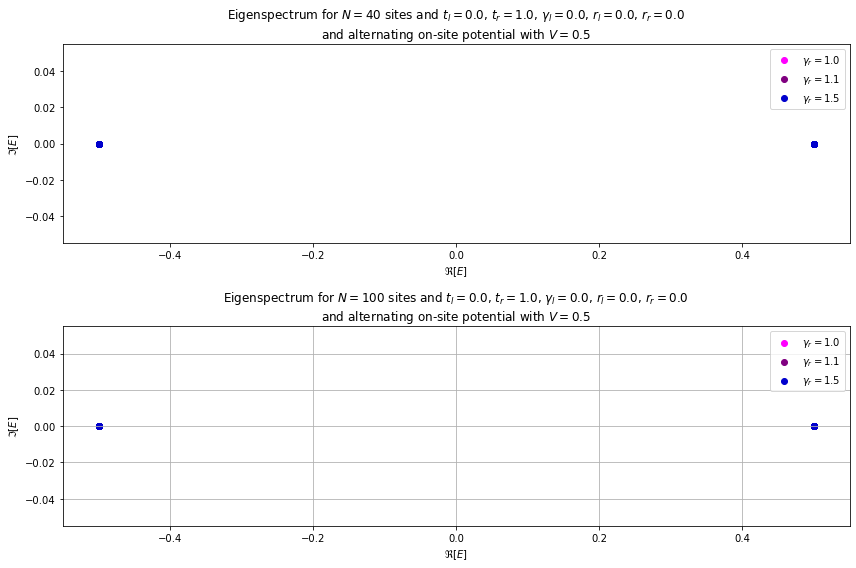

In [33]:
# Define quantities:
sites_small = 40
sites_large = 100
tl = 0.0    # FIXED as unit of energy
tr = 1.0
gam_l = 0.0
gam_r_list = [1.0, 1.1, 1.5]
V = 0.5
rl = 0.0
rr = 0.0

onsite_pot_small = NHI.alternating_onsite_pot(N = sites_small,
                                              V = V)
onsite_pot_large = NHI.alternating_onsite_pot(N = sites_large,
                                              V = V)


evals_real_list_small = []
evals_imag_list_small = []
for idx, gam_r in enumerate(gam_r_list): 
    Ham_small = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_small,
                                             V_pot = onsite_pot_small,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_small)
    evals_real_list_small.append(evals_real)
    evals_imag_list_small.append(evals_imag)


evals_real_list_large = []
evals_imag_list_large = []
for idx, gam_r in enumerate(gam_r_list): 
    Ham_large = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_large,
                                              V_pot = onsite_pot_large,
                                              tl = tl,
                                              tr = tr,
                                              gam_l = gam_l,
                                              gam_r = gam_r,
                                              rl = rl,
                                              rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_large)
    evals_real_list_large.append(evals_real)
    evals_imag_list_large.append(evals_imag)
    

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
for idx, gam_r in enumerate(gam_r_list):
    plot = ax1.scatter(evals_real_list_small[idx], evals_imag_list_small[idx], color=colorlist[idx], label=r"$\gamma_r=$%s"%(gam_r))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(sites_small, tl, tr, gam_l, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")

ax1 = fig.add_subplot(212)
for idx, gam_r in enumerate(gam_r_list):
    plot = ax1.scatter(evals_real_list_large[idx], evals_imag_list_large[idx], color=colorlist[idx], label=r"$\gamma_r=$%s"%(gam_r))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(sites_large, tl, tr, gam_l, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")

plt.tight_layout()
plt.grid()
plt.show()

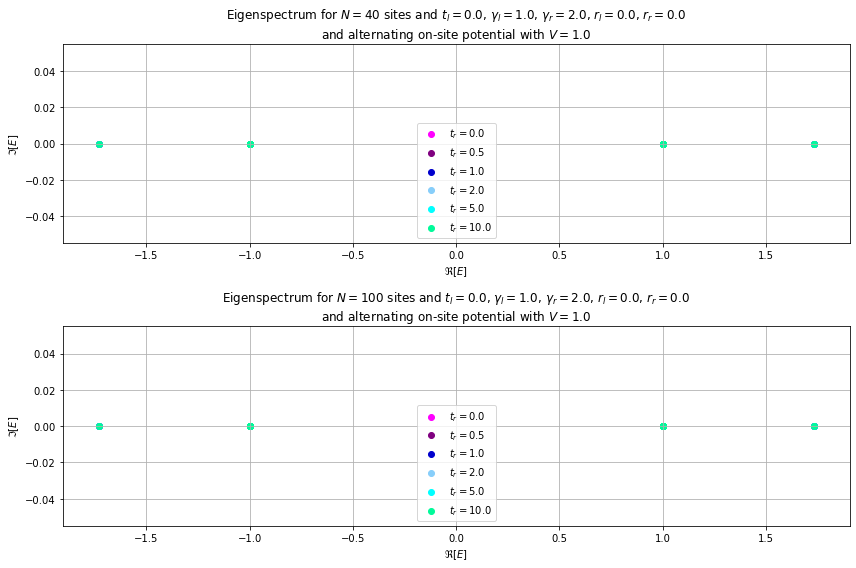

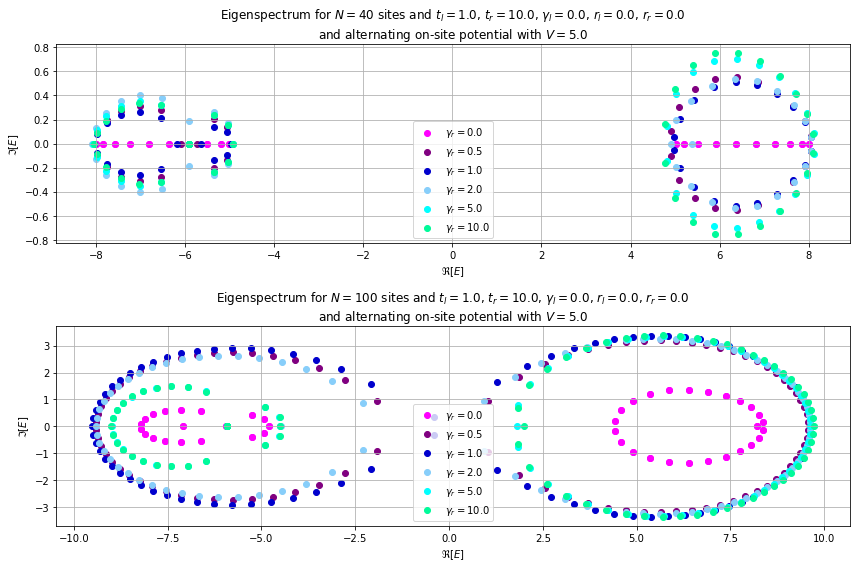

In [34]:
# Define quantities:
sites_small = 40
sites_large = 100
tl = 0.0    # FIXED as unit of energy
tr_list = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
gam_l = 1.0
gam_r = 2.0
V = 1.0
rl = 0.0
rr = 0.0

onsite_pot_small = NHI.alternating_onsite_pot(N = sites_small,
                                              V = V)
onsite_pot_large = NHI.alternating_onsite_pot(N = sites_large,
                                              V = V)


evals_real_list_small = []
evals_imag_list_small = []
for idx, tr in enumerate(tr_list): 
    Ham_small = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_small,
                                              V_pot = onsite_pot_small,
                                              tl = tl,
                                              tr = tr,
                                              gam_l = gam_l,
                                              gam_r = gam_r,
                                              rl = rl,
                                              rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_small)
    evals_real_list_small.append(evals_real)
    evals_imag_list_small.append(evals_imag)


evals_real_list_large = []
evals_imag_list_large = []
for idx, tr in enumerate(tr_list): 
    Ham_large = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_large,
                                               V_pot = onsite_pot_large,
                                               tl = tl,
                                               tr = tr,
                                               gam_l = gam_l,
                                               gam_r = gam_r,
                                               rl = rl,
                                               rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_large)
    evals_real_list_large.append(evals_real)
    evals_imag_list_large.append(evals_imag)
    

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
for idx, tr in enumerate(tr_list):
    plot = ax1.scatter(evals_real_list_small[idx], evals_imag_list_small[idx], color=colorlist[idx], label=r"$t_r=$%s"%(tr))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(sites_small, tl, gam_l, gam_r, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")
plt.grid()

ax1 = fig.add_subplot(212)
for idx, tr in enumerate(tr_list):
    plot = ax1.scatter(evals_real_list_large[idx], evals_imag_list_large[idx], color=colorlist[idx], label=r"$t_r=$%s"%(tr))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s"%(sites_large, tl, gam_l, gam_r, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")

plt.tight_layout()
plt.grid()
plt.show()

###################################################################################################################
###################################################################################################################

# Define quantities:
sites_small = 40
sites_large = 100
tl = 1.0    # FIXED as unit of energy
gam_r_list = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
gam_l = 0.0
t_r = 2.0
V = 5.0
rl = 0.0
rr = 0.0

onsite_pot_small = NHI.alternating_onsite_pot(N = sites_small,
                                              V = V)
onsite_pot_large = NHI.alternating_onsite_pot(N = sites_large,
                                              V = V)


evals_real_list_small = []
evals_imag_list_small = []
for idx, gam_r in enumerate(gam_r_list): 
    Ham_small = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_small,
                                              V_pot = onsite_pot_small,
                                              tl = tl,
                                              tr = tr,
                                              gam_l = gam_l,
                                              gam_r = gam_r,
                                              rl = rl,
                                              rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_small)
    evals_real_list_small.append(evals_real)
    evals_imag_list_small.append(evals_imag)


evals_real_list_large = []
evals_imag_list_large = []
for idx, gam_r in enumerate(gam_r_list): 
    Ham_large = NHI.Hatano_Nelson_plus_pot_Ham(N = sites_large,
                                               V_pot = onsite_pot_large,
                                               tl = tl,
                                               tr = tr,
                                               gam_l = gam_l,
                                               gam_r = gam_r,
                                               rl = rl,
                                               rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham_large)
    evals_real_list_large.append(evals_real)
    evals_imag_list_large.append(evals_imag)
    

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
for idx, gam_r in enumerate(gam_r_list):
    plot = ax1.scatter(evals_real_list_small[idx], evals_imag_list_small[idx], color=colorlist[idx], label=r"$\gamma_r=$%s"%(gam_r))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(sites_small, tl, tr, gam_l, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")
plt.grid()

ax1 = fig.add_subplot(212)
for idx, gam_r in enumerate(gam_r_list):
    plot = ax1.scatter(evals_real_list_large[idx], evals_imag_list_large[idx], color=colorlist[idx], label=r"$\gamma_r=$%s"%(gam_r))
ax1.set_xlabel(r"$\Re[E]$")
ax1.set_ylabel(r"$\Im[E]$")
ax1.set_title(r"Eigenspectrum for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(sites_large, tl, tr, gam_l, rl, rr)+"\n"+r"and alternating on-site potential with $V=$%s"%(V))
plt.legend(loc="best")

plt.tight_layout()
plt.grid()
plt.show()

#### Plotting eigenvectors

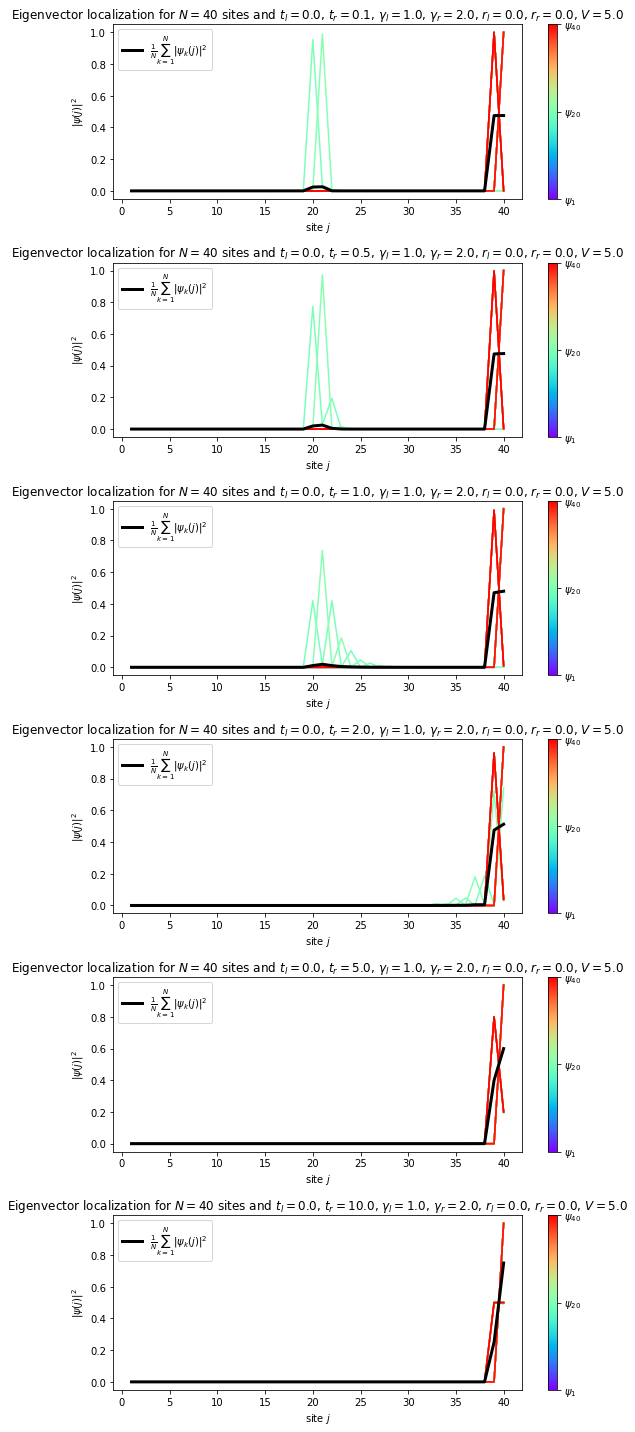

In [36]:
# Define quantities:
N = 40
site_array = np.linspace(1,N,N) 
tl = 0.0
tr_list = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
gam_l = 1.0
gam_r = 2.0
rl = 0.0
rr = 0.0
V = 5.0

colors = plt.cm.rainbow(np.linspace(0,1,N))
onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)

REvecs_list = []
ass_list = []
for idx, tr in enumerate(tr_list): 
    Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                         V_pot = onsite_pot,
                                         tl = tl,
                                         tr = tr,
                                         gam_l = gam_l,
                                         gam_r = gam_r,
                                         rl = rl,
                                         rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
    REvecs_list.append(REvecs)
    ass_list.append(abs_square_sum_r)
    
    
# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))
ax1 = fig.add_subplot(611)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[0])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[0]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,0])**2, color="red" , label=r"$\psi_{1}$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,24])**2, color="green", label=r"$\psi_{24}$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[0], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(612)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[1])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[1]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[1], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(613)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[2])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[2]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[2], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(614)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[3])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[3]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[3], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(615)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[4])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[4]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[4], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(616)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[5])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[5]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[5], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

plt.tight_layout()
plt.show()

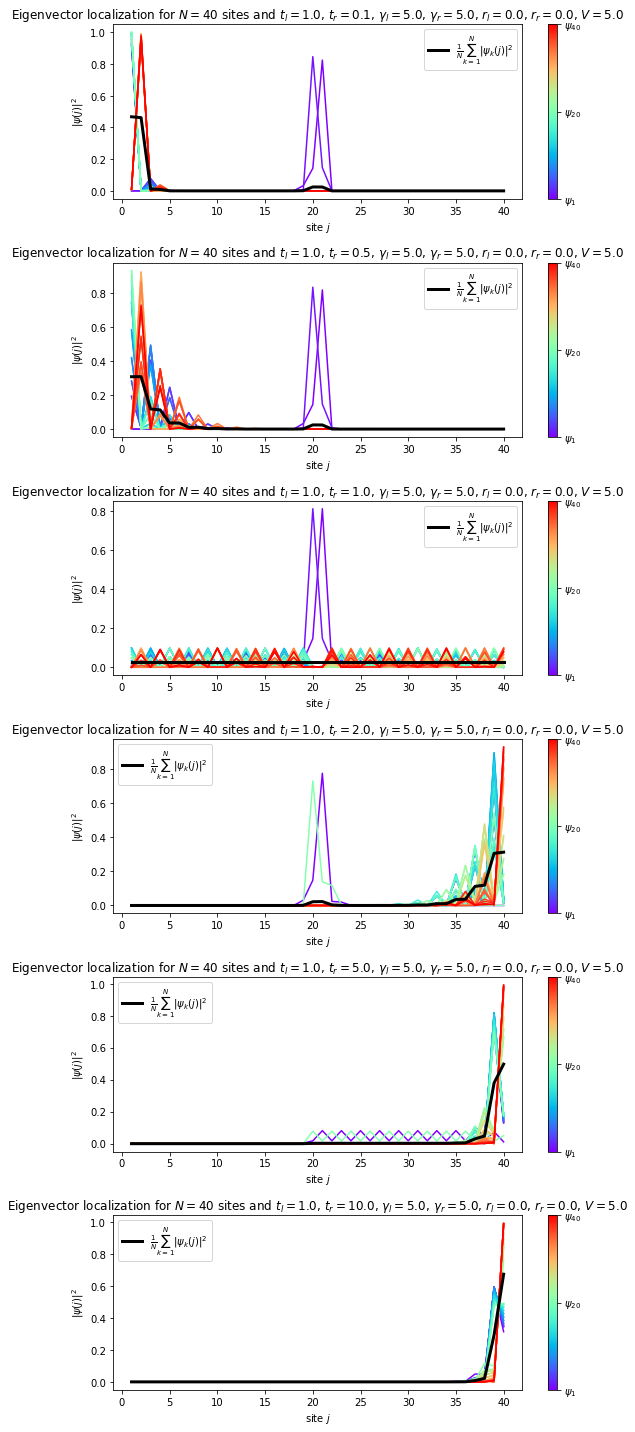

In [20]:
# Define quantities:
N = 40
site_array = np.linspace(1,N,N) 
tl = 0.0
tr_list = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
gam_l = 5.0
gam_r = 5.0
rl = 0.0
rr = 0.0
V = 5.0

colors = plt.cm.rainbow(np.linspace(0,1,N))
onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)

REvecs_list = []
ass_list = []
for idx, tr in enumerate(tr_list): 
    Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                         V_pot = onsite_pot,
                                         tl = tl,
                                         tr = tr,
                                         gam_l = gam_l,
                                         gam_r = gam_r,
                                         rl = rl,
                                         rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
    REvecs_list.append(REvecs)
    ass_list.append(abs_square_sum_r)
    
    
# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))
ax1 = fig.add_subplot(611)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[0])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[0]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,0])**2, color="red" , label=r"$\psi_{1}$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,24])**2, color="green", label=r"$\psi_{24}$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[0], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(612)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[1])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[1]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[1], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(613)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[2])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[2]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[2], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(614)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[3])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[3]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[3], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(615)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[4])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[4]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[4], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(616)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[5])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[5]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl, tr_list[5], gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

plt.tight_layout()
plt.show()

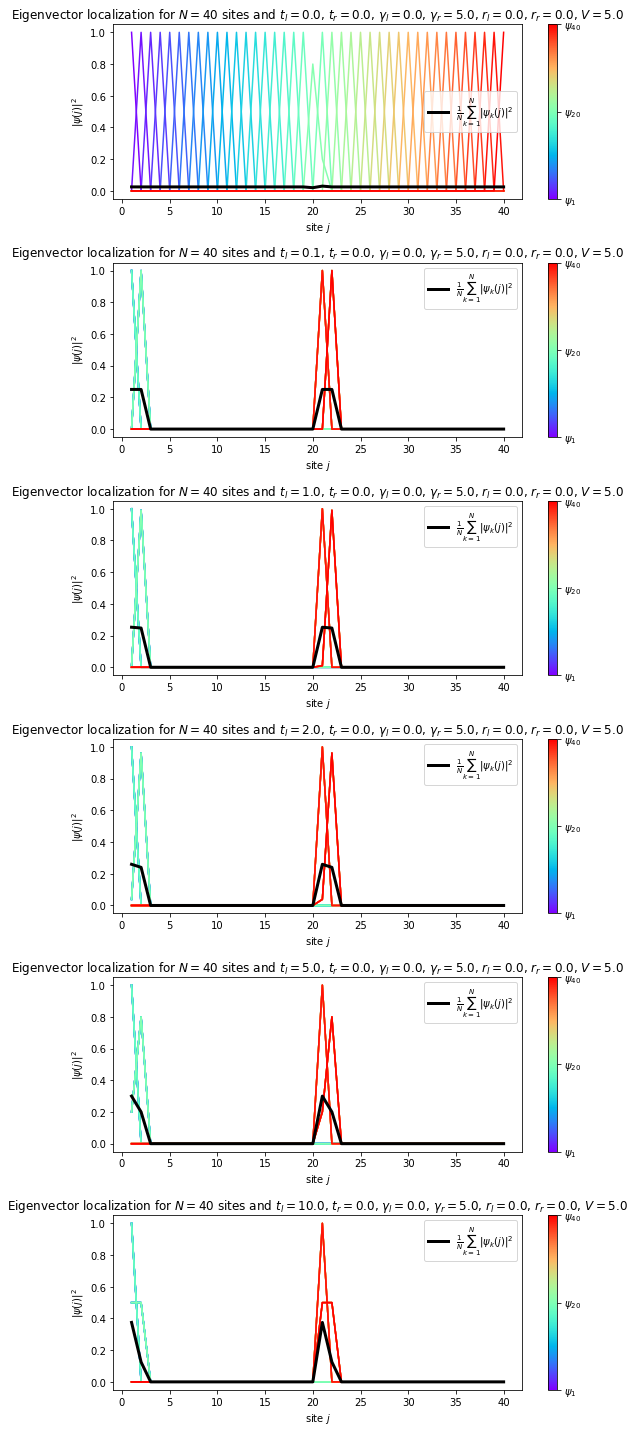

In [22]:
# Define quantities:
N = 40
site_array = np.linspace(1,N,N) 
tr = 0.0
tl_list = [0.0, 0.1, 1.0, 2.0, 5.0, 10.0]
gam_l = 0.0
gam_r = 5.0
rl = 0.0
rr = 0.0
V = 5.0

colors = plt.cm.rainbow(np.linspace(0,1,N))
onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)

REvecs_list = []
ass_list = []
for idx, tl in enumerate(tl_list): 
    Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                         V_pot = onsite_pot,
                                         tl = tl,
                                         tr = tr,
                                         gam_l = gam_l,
                                         gam_r = gam_r,
                                         rl = rl,
                                         rr = rr)
    evals_real, evals_imag, LEvecs, REvecs, abs_square_sum_r, abs_square_sum_l = NHI.extract_spectrum(Ham)
    REvecs_list.append(REvecs)
    ass_list.append(abs_square_sum_r)
    
    
# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))
ax1 = fig.add_subplot(611)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[0])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[0]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,0])**2, color="red" , label=r"$\psi_{1}$")
#ax1.plot(site_array, np.abs((REvecs_list[0])[:,24])**2, color="green", label=r"$\psi_{24}$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[0], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(612)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[1])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[1]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[1], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(613)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[2])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[2]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[2], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(614)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[3])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[3]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[3], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(615)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[4])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[4]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[4], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

ax1 = fig.add_subplot(616)
for i in range(N):
    ax1.plot(site_array, np.abs((REvecs_list[5])[:,i])**2, color=colors[i])
ax1.plot(site_array, ass_list[5]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_xlabel(r"site $j$")
ax1.set_ylabel(r"$|\psi(j)|^2$")
ax1.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, $V=$%s"%(N, tl_list[5], tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax1, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# Disordered potential - Random potential 

#### Plotting eigenvalues

0.0% of program complete.
10.0% of program complete.
20.0% of program complete.
30.0% of program complete.
40.0% of program complete.
50.0% of program complete.
60.0% of program complete.
70.0% of program complete.
80.0% of program complete.
90.0% of program complete.


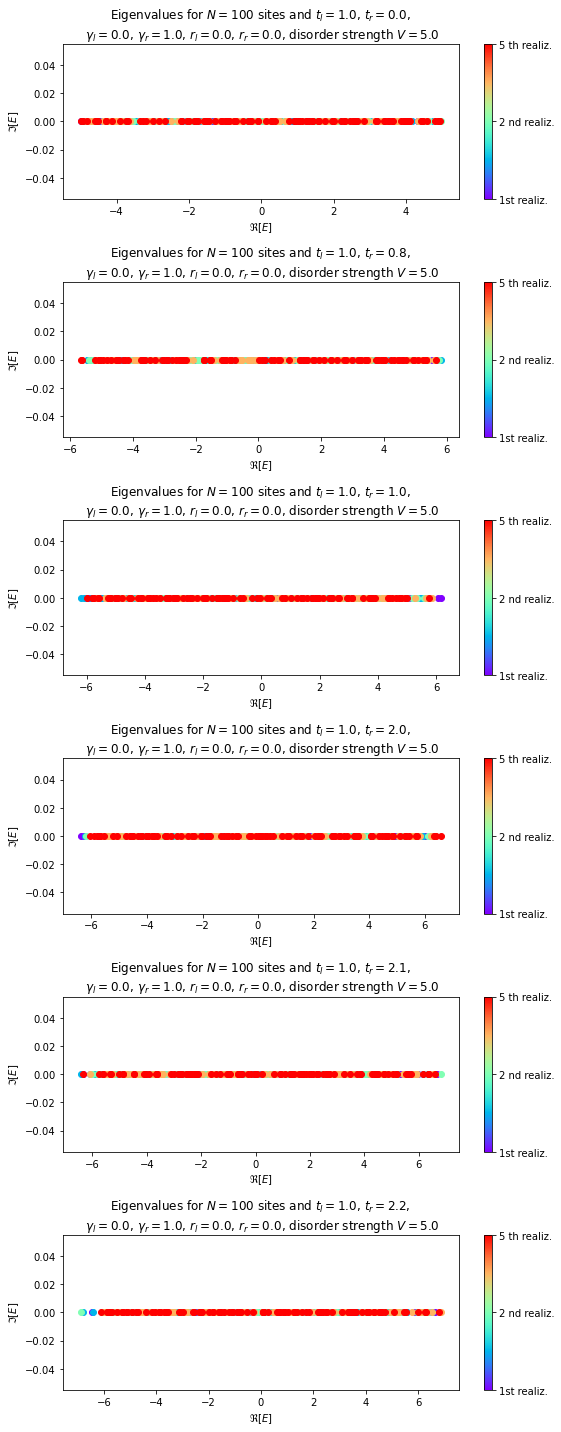

In [15]:
# Define quantities:
N = 100
tr_list = [0.0, 0.8, 1.0, 2.0, 2.1, 2.2]
tl = 1.0
gam_l = 0.0
gam_r = 1.0
rl = 0.0
rr = 0.0
V = 5.0
N_realizations = 5

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))


onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)


evals_real_list = []
evals_imag_list = []
for idx, tr in enumerate(tr_list):
    evals_real = []
    evals_imag = []
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
        Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR  = NHI.extract_spectrum(Ham)
        evals_real.append(Evals_real)
        evals_imag.append(Evals_imag)

        
        percentage = (idx*N_realizations + realiz)/(N_realizations*len(tr_list))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    evals_real_list.append(evals_real)
    evals_imag_list.append(evals_imag)

    
fig = plt.figure(figsize=(8,20))
#disorder_avg_real = np.zeros(sites)
#disorder_avg_imag = np.zeros(sites)
for idx, tr in enumerate(tr_list):
    ax_value = len(tr_list)*100 + 10 + idx+1
    ax = fig.add_subplot(6,1,idx+1)
    for i in range(N_realizations):
        ax.scatter(np.array(evals_real_list[idx])[i,:], np.array(evals_imag_list[idx])[i,:], color=colors[i])
        #disorder_avg_real += np.array(evals_real_list[0])[i,:] 
    #ax1.plot(site_array, disorder_avg/N_realizations, color="black", lw=3, label=r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
    ax.set_xlabel(r"$\Re[E]$")
    ax.set_ylabel(r"$\Im[E]$")
    ax.set_title(r"Eigenvalues for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, disorder strength $V=$%s"%(N, tl, tr_list[idx], gam_l, gam_r, rl, rr, V))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"1st realiz.", r"%s nd realiz."%(int(N_realizations/2)), r"%s th realiz."%(int(N_realizations))])
plt.tight_layout()
plt.show()

#### Plotting eigenvectors

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

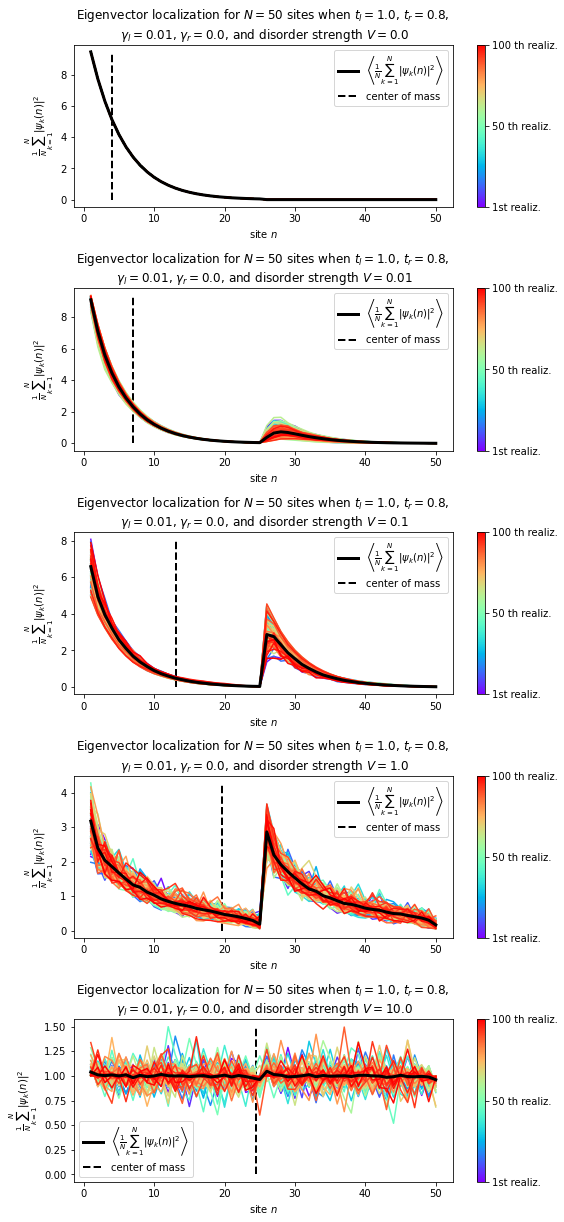

In [14]:
## V variation

# Define quantities:
N = 50
site_array = np.linspace(1,N,N) 
# tr_list = [0.0, 0.5, 1.0, 2.0, 2.1, 2.2]
tl = 1.0
tr = 0.8
gam_l = 0.01
gam_r = 0.0
rl = 0.0
rr = 0.0
V_list = [0.0, 0.01, 0.1, 1., 10.]
N_realizations = 100

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

ass_list = []    
for idx, V in enumerate(V_list):
    ass_list_realiz = []
    for realiz in range(N_realizations):
        # onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)
        onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
        Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR  = NHI.extract_spectrum(Ham)
        ass_list_realiz.append(abs_square_sum_r)
        
        percentage = (idx*N_realizations + realiz)/(N_realizations*len(V_list))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    ass_list.append(ass_list_realiz)


# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))

for idx, V in enumerate(V_list):
    ax_value = len(V_list)*100 + 10 + idx+1
    ax = fig.add_subplot(6, 1, idx+1) 
    
    min_val = 0
    max_val = 0
    disorder_avg = np.zeros(N)
    for i in range(N_realizations):
        avg_localiz = np.array(ass_list[idx])[i,:]
        ax.plot(site_array, avg_localiz, color=colors[i])
        disorder_avg += avg_localiz 
        
        # Determine min/max for vertical line indicating com:
        if min_val > np.amin(avg_localiz):
            min_val = np.amin(avg_localiz)
        if max_val < np.amax(avg_localiz):
            max_val = np.amax(avg_localiz)

    ax.plot(site_array, disorder_avg/N_realizations, color="black", lw=3, label=r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(n)|^2 \right>$")
    
    #com:
    com = 0
    for idx_com, i in enumerate(disorder_avg):
        com += i*idx_com
    com /= np.sum(disorder_avg)      
    ax.vlines(x=com, ymin=min_val, ymax=max_val, color="black", linestyle="dashed", lw=2, label=r"center of mass")
    
    ax.set_xlabel(r"site $n$")
    ax.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(n)|^2$")
    # ax.set_title(r"Eigenvector localization for $N=$%s sites when $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, and alternating potential of $V=$%s"%(N, tl, tr, gam_l, gam_r, V))
    ax.set_title(r"Eigenvector localization for $N=$%s sites when $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, and disorder strength $V=$%s"%(N, tl, tr, gam_l, gam_r, V))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"1st realiz.", r"%s th realiz."%(int(N_realizations/2)), r"%s th realiz."%(int(N_realizations))])
    plt.legend(loc='best')
plt.tight_layout()
plt.show()

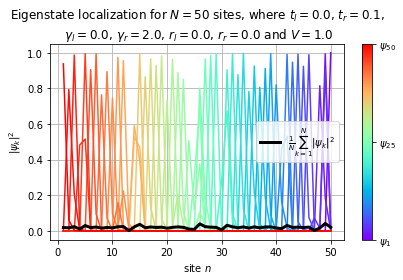

In [21]:

N = 50 # !!! MUST BE EVEN NUMBERED, N >=4
tl = 0.0 # FIXED as unit of energy, left hoppings
tr = 0.1 # FIXED as unit of energy, right hoppings
rl = 0.0 # Open boundaries, i.e. left boundary hopping value
rr = 0.0 # right boundary hopping value
gam_l = 0.0 # Impurity in the middle of the sequence, left hopping
gam_r = 2.0 # Impurity in the middle of the sequence, right hopping
V = 1.0

#onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)

random_onsite_pot = NHI.random_onsite_pot(N=N, low=-1., high=1., V=V)
# alternating_onsite_pot = NHI.alternating_onsite_pot(N = N, V = V)


# extract a discretized set of colors from the rainbow
colors = plt.cm.rainbow(np.linspace(0,1,N))
colorlist = ['fuchsia', 'purple', 'mediumblue',  'lightskyblue', 'aqua', 'mediumspringgreen', 'green', 'yellowgreen', 'gold', 'orange', 'peru', 'red', 'brown' ]

Ham = NHI.Hatano_Nelson_plus_pot_Ham(V_pot = random_onsite_pot , 
                                      tl = tl,
                                      tr = tr,
                                      gam_l = gam_l,
                                      gam_r = gam_r,
                                      rl = rl,
                                      rr = rr,
                                      N = N)


Evals_real, Evals_imag, LEvecs, REvecs, abs_square_sum_l, abs_square_sum_r, IPR = NHI.extract_spectrum(Ham)


fig = plt.figure()
ax2 = fig.add_subplot(111)
site_array = np.linspace(1,N,N) 

#Iterate over all right eigenvectors:
for i in range(N):
    ax2.plot(site_array, np.abs(REvecs[:,i])**2, color=colors[i])
    # print(REvecs[:,i])
ax2.plot(site_array, abs_square_sum_r/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k|^2$")
ax2.set_xlabel(r"site $n$")
ax2.set_ylabel(r"$|\psi_k|^2$")
ax2.set_title(r"Eigenstate localization for $N=$%s sites, where $t_l=$%s, $t_r=$%s,""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s and $V=$%s"%(N, tl, tr, gam_l, gam_r, rl, rr, V))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax2, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show() 


0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

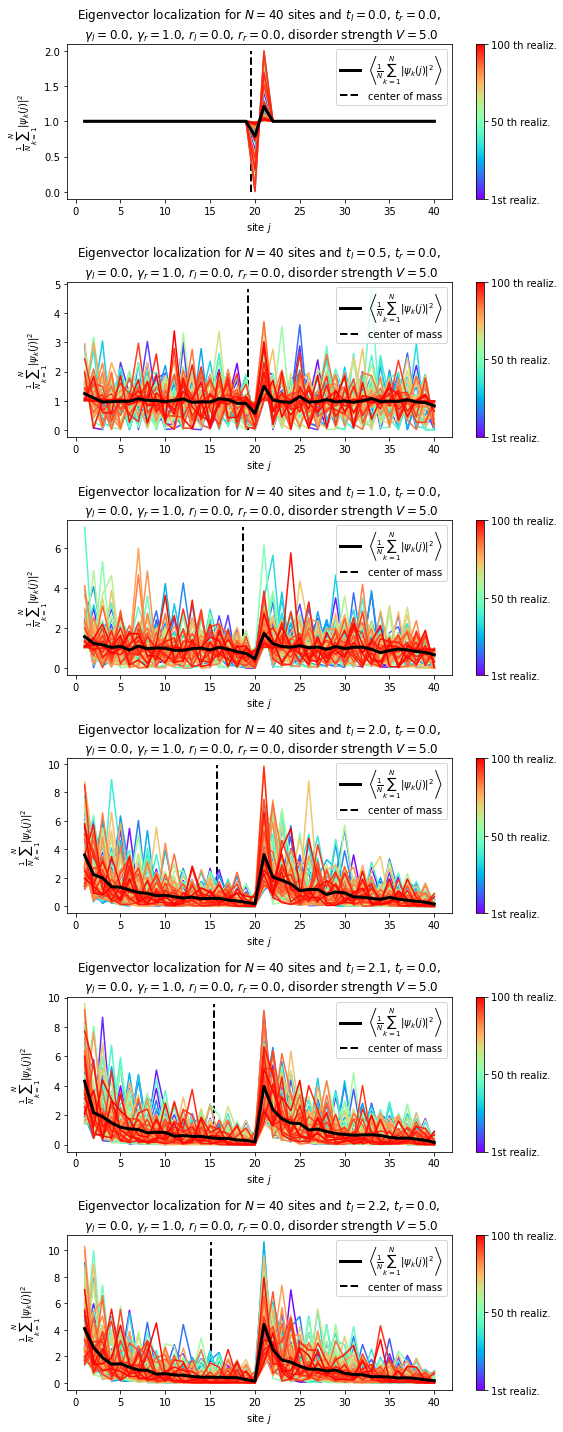

In [5]:
## t_l variation

# Define quantities:
N = 40
site_array = np.linspace(1,N,N) 
tl_list = [0.0, 0.5, 1.0, 2.0, 2.1, 2.2]
tr = 0.0
gam_l = 0.0
gam_r = 1.0
rl = 0.0
rr = 0.0
V = 5.0
N_realizations = 100

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)

ass_list = []    
for idx, tl in enumerate(tl_list):
    ass_list_realiz = []
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
        _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
        ass_list_realiz.append(abs_square_sum_r)
        
        percentage = (idx*N_realizations + realiz)/(N_realizations*len(tr_list))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    ass_list.append(ass_list_realiz)
    
#print(np.array(ass_list[0])[0,:])

# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))

for idx, tl in enumerate(tl_list):
    ax_value = len(tl_list)*100 + 10 + idx+1
    ax = fig.add_subplot(6, 1, idx+1) 
    
    min_val = 0
    max_val = 0
    disorder_avg = np.zeros(N)
    for i in range(N_realizations):
        avg_localiz = np.array(ass_list[idx])[i,:]
        ax.plot(site_array, avg_localiz, color=colors[i])
        disorder_avg += avg_localiz 
        
        # Determine min/max for vertical line indicating com:
        if min_val > np.amin(avg_localiz):
            min_val = np.amin(avg_localiz)
        if max_val < np.amax(avg_localiz):
            max_val = np.amax(avg_localiz)

    ax.plot(site_array, disorder_avg/N_realizations, color="black", lw=3, label=r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
    
    #com:
    com = 0
    for idx_com, i in enumerate(disorder_avg):
        com += i*idx_com
    com /= np.sum(disorder_avg)      
    ax.vlines(x=com, ymin=min_val, ymax=max_val, color="black", linestyle="dashed", lw=2, label=r"center of mass")
    
    ax.set_xlabel(r"site $j$")
    ax.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
    ax.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, disorder strength $V=$%s"%(N, tl_list[idx], tr, gam_l, gam_r, rl, rr, V))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"1st realiz.", r"%s th realiz."%(int(N_realizations/2)), r"%s th realiz."%(int(N_realizations))])
    plt.legend(loc='best')
plt.tight_layout()
plt.show()

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

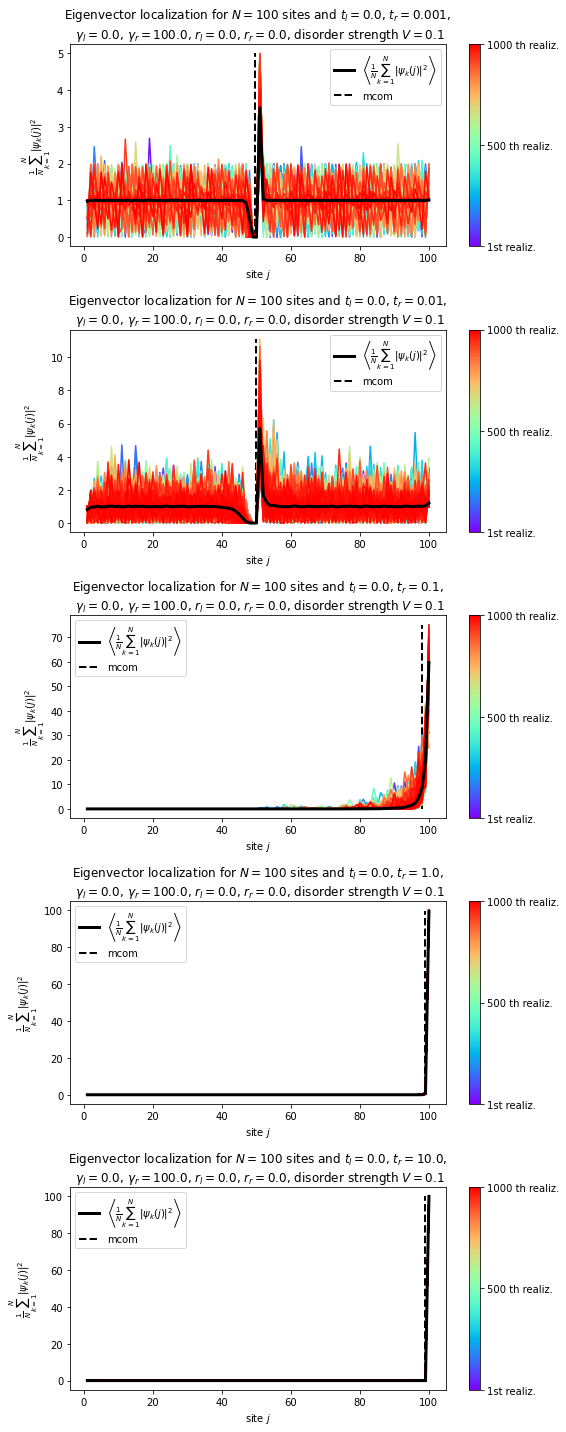

In [33]:
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################
                                 ## t_r variation           
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################

# Define quantities:
N = 100
site_array = np.linspace(1,N,N) 
tr_list = [0.001, 0.01, 0.1, 1., 10.] #[1.8, 1.9, 2.0, 2.1, 2.2, 2.3]
tl = 0.0
gam_l = 0.0
gam_r = 100.0
rl = 0.0
rr = 0.0
V = 0.1
N_realizations = 1000

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)

ass_list = []    
for idx, tr in enumerate(tr_list):
    ass_list_realiz = []
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
        _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
        ass_list_realiz.append(abs_square_sum_r)
        
        percentage = (idx*N_realizations + realiz)/(N_realizations*len(tr_list))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    ass_list.append(ass_list_realiz)
    
#print(np.array(ass_list[0])[0,:])

# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))

for idx, tr in enumerate(tr_list):
    ax_value = len(tr_list)*100 + 10 + idx+1
    ax = fig.add_subplot(5, 1, idx+1) 
    
    min_val = 0
    max_val = 0
    disorder_avg = np.zeros(N)
    for i in range(N_realizations):
        avg_localiz = np.array(ass_list[idx])[i,:]
        ax.plot(site_array, avg_localiz, color=colors[i])
        disorder_avg += avg_localiz 
        
        # Determine min/max for vertical line indicating com:
        if min_val > np.amin(avg_localiz):
            min_val = np.amin(avg_localiz)
        if max_val < np.amax(avg_localiz):
            max_val = np.amax(avg_localiz)

    ax.plot(site_array, disorder_avg/N_realizations, color="black", lw=3, label=r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
    
    #com:
    com = 0
    for idx_com, i in enumerate(disorder_avg):
        com += i*idx_com
    com /= np.sum(disorder_avg)      
    ax.vlines(x=com, ymin=min_val, ymax=max_val, color="black", linestyle="dashed", lw=2, label=r"mcom")
    
    ax.set_xlabel(r"site $j$")
    ax.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
    ax.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, disorder strength $V=$%s"%(N, tl, tr_list[idx], gam_l, gam_r, rl, rr, V))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"1st realiz.", r"%s th realiz."%(int(N_realizations/2)), r"%s th realiz."%(int(N_realizations))])
    plt.legend(loc='best')
plt.tight_layout()
plt.show()

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

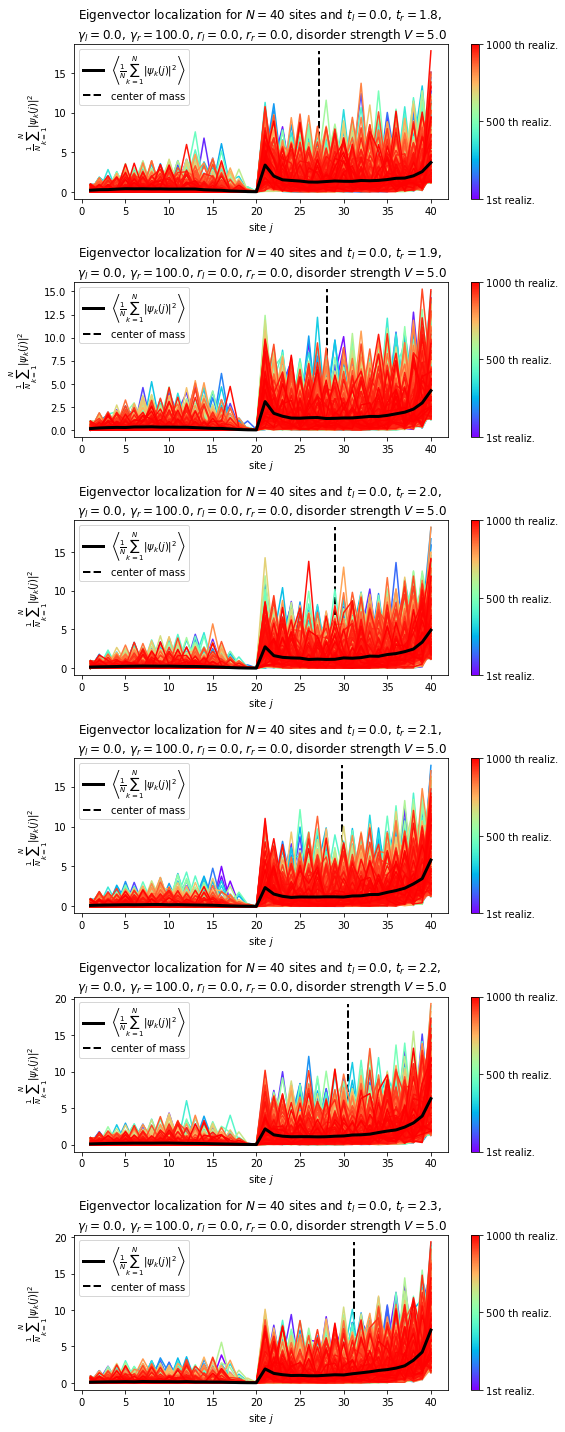

In [151]:
## t_r variation

# Define quantities:
N = 40
site_array = np.linspace(1,N,N) 
tr_list = [1.8, 1.9, 2.0, 2.1, 2.2, 2.3]
tl = 0.0
gam_l = 0.0
gam_r = 100.0
rl = 0.0
rr = 0.0
V = 5.0
N_realizations = 1000

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)

ass_list = []    
for idx, tr in enumerate(tr_list):
    ass_list_realiz = []
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             gam_l = gam_l,
                                             gam_r = gam_r,
                                             rl = rl,
                                             rr = rr)
        _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
        ass_list_realiz.append(abs_square_sum_r)
        
        percentage = (idx*N_realizations + realiz)/(N_realizations*len(tr_list))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    ass_list.append(ass_list_realiz)
    
#print(np.array(ass_list[0])[0,:])

# Iterate over all eigenvectors:
fig = plt.figure(figsize=(8,20))

for idx, tr in enumerate(tr_list):
    ax_value = len(tr_list)*100 + 10 + idx+1
    ax = fig.add_subplot(6, 1, idx+1) 
    
    min_val = 0
    max_val = 0
    disorder_avg = np.zeros(N)
    for i in range(N_realizations):
        avg_localiz = np.array(ass_list[idx])[i,:]
        ax.plot(site_array, avg_localiz, color=colors[i])
        disorder_avg += avg_localiz 
        
        # Determine min/max for vertical line indicating com:
        if min_val > np.amin(avg_localiz):
            min_val = np.amin(avg_localiz)
        if max_val < np.amax(avg_localiz):
            max_val = np.amax(avg_localiz)

    ax.plot(site_array, disorder_avg/N_realizations, color="black", lw=3, label=r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
    
    #com:
    com = 0
    for idx_com, i in enumerate(disorder_avg):
        com += i*idx_com
    com /= np.sum(disorder_avg)      
    ax.vlines(x=com, ymin=min_val, ymax=max_val, color="black", linestyle="dashed", lw=2, label=r"center of mass")
    
    ax.set_xlabel(r"site $j$")
    ax.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
    ax.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $r_l=$%s, $r_r=$%s, disorder strength $V=$%s"%(N, tl, tr_list[idx], gam_l, gam_r, rl, rr, V))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"1st realiz.", r"%s th realiz."%(int(N_realizations/2)), r"%s th realiz."%(int(N_realizations))])
    plt.legend(loc='best')
plt.tight_layout()
plt.show()

#### Plot the full eigenvectors for a few selected disorder realizations

0.0% of program complete.
20.0% of program complete.
40.0% of program complete.
60.0% of program complete.
80.0% of program complete.


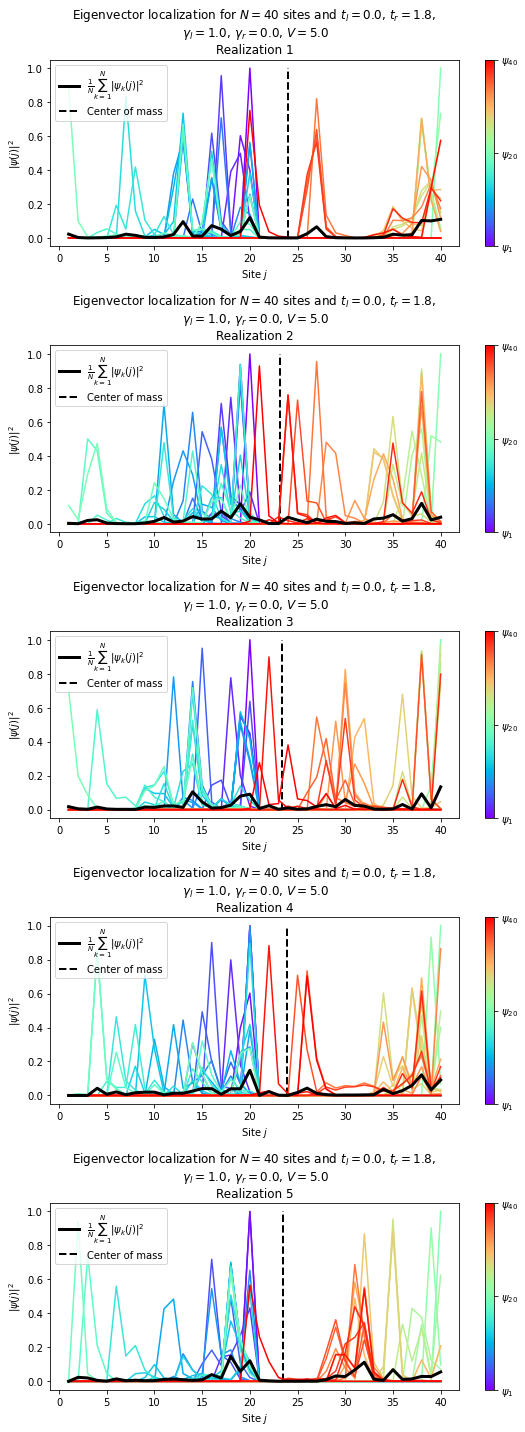

In [33]:
# Plot the full eigenvectors for a few selected disorder realizations
N = 40
site_array = np.linspace(1,N,N) 
tl = 0.0
tr = 1.8
gam_l = 1.0
gam_r = 0.0
rl = 0.0
rr = 0.0
V = 5.0
N_realizations = 5

colors = plt.cm.rainbow(np.linspace(0,1,N))


ass_list_realiz = []
REvecs_list_realiz = []
com_list = []
for realiz in range(N_realizations):
    onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
    Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                         V_pot = onsite_pot,
                                         tl = tl,
                                         tr = tr,
                                         gam_l = gam_l,
                                         gam_r = gam_r,
                                         rl = rl,
                                         rr = rr)
    _, _, _, REvecs, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
    
    # Calculating com:
    com = 0
    for idx, i in enumerate(abs_square_sum_r):
        com += i*idx
    com /= np.sum(abs_square_sum_r)   
    
    # Appending data:
    com_list.append(com)
    ass_list_realiz.append(abs_square_sum_r)
    REvecs_list_realiz.append(REvecs)
       
    # Checking computation progress:
    percentage = realiz/(N_realizations)*100
    if percentage%20==0:
        print(f"{percentage}% of program complete.")
        
fig = plt.figure(figsize=(8,20))

# Iterate over all realizations (one panel for each realization):
for realiz in range(N_realizations):
    ax_value = N_realizations*100 + 10 + realiz+1
    ax = fig.add_subplot(ax_value)
    
    min_val = 0
    max_val = 0
    for i in range(N):
        abs_square = np.abs(np.array(REvecs_list_realiz[realiz])[:,i])**2
        ax.plot(site_array, abs_square, color=colors[i])
        
        # Determine min/max for vertical line indicating com:
        if min_val > np.amin(abs_square):
            min_val = np.amin(abs_square)
        if max_val < np.amax(abs_square):
            max_val = np.amax(abs_square)
            
    ax.vlines(x=com_list[realiz], ymin=min_val, ymax=max_val, color="black", linestyle="dashed", lw=2, label=r"Center of mass")
    ax.plot(site_array, ass_list_realiz[realiz]/N, color="black", lw=3, label=r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
    ax.set_xlabel(r"Site $j$")
    ax.set_ylabel(r"$|\psi(j)|^2$")
    ax.set_title(r"Eigenvector localization for $N=$%s sites and $t_l=$%s, $t_r=$%s, ""\n"" $\gamma_l=$%s, $\gamma_r=$%s, $V=$%s"%(N, tl, tr, gam_l, gam_r, V)+"\n"+r"Realization %s"%(realiz+1))
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=None, cmap="rainbow"), ax=ax, ticks=[0, 0.5, 1])
    cbar.ax.set_yticklabels([r"$\psi_1$", r"$\psi_{%s}$"%(int(N/2)), r"$\psi_{%s}$"%(int(N))])
    plt.legend(loc='best')
    
plt.tight_layout()
plt.show()

#### Phase diagram by calculating center of mass of avg eigenvector localization

In [35]:
N = 40
tl = 0.0
tr_array = 10**(np.linspace(-3,3,50))
gam_l = 0.0
gam_r_array = 10**(np.linspace(-3,3,51))
rl = 0.0
rr = 0.0
V_array = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]
N_realizations = 1000

com_array = np.zeros(shape=(len(tr_array), len(gam_r_array), len(V_array)))
for idx_V, V in enumerate(V_array):
    for idx_tr, tr in enumerate(tr_array):
        for idx_gam_r, gam_r in enumerate(gam_r_array):
            realiz_avg = 0
            for realiz in range(N_realizations):
                onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
                Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                                     V_pot = onsite_pot,
                                                     tl = tl,
                                                     tr = tr,
                                                     gam_l = gam_l,
                                                     gam_r = gam_r,
                                                     rl = rl,
                                                     rr = rr)
                _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
                
                realiz_avg += abs_square_sum_r
        
            realiz_avg /= N_realizations
        
            com = 0
            for idx, i in enumerate(realiz_avg):
                com += i*idx
            com /= np.sum(realiz_avg)        
            com_array[idx_tr, idx_gam_r, idx_V] = com
        
        percentage = (idx_V*len(tr_array) + idx_tr )/(len(V_array)*len(tr_array))*100
        if np.round(percentage,0)%5==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure(figsize=(6,20))
X, Y = np.meshgrid(gam_r_array, tr_array)   


for idx_V, V in enumerate(V_array):
    ax_value = len(V_array)*100 + 10 + idx_V + 1
    ax = fig.add_subplot(ax_value)
    
    heatmap = ax.pcolormesh(X, Y, com_array[:, :, idx_V], vmin = 1, vmax = N, cmap="inferno", shading="auto")
                     
    ax.set_xlabel(r"$\gamma_r$")
    ax.set_ylabel(r"$t_r$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(r"Center of mass localization for $N=$%s sites and $t_l=$%s, $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(N, tl, gam_l, rl, rr)+"\n"+r"and disorder strength $V=$%s with $N_r=$%s realizations"%(V, N_realizations))
    cbar = plt.colorbar(heatmap, ticks = [1, N/2, N])
    cbar.ax.set_yticklabels([r"$N = 1$", r"$N = {%s}$"%(int(N/2)), r"$N = {%s}$"%(int(N))])
    
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

0.0% of calculation completed.
0.33333333333333337% of calculation completed.
4.666666666666667% of calculation completed.
5.0% of calculation completed.
5.333333333333334% of calculation completed.
9.666666666666666% of calculation completed.
10.0% of calculation completed.
10.333333333333334% of calculation completed.
14.666666666666666% of calculation completed.
15.0% of calculation completed.
15.333333333333332% of calculation completed.
19.666666666666664% of calculation completed.
20.0% of calculation completed.
20.333333333333332% of calculation completed.
24.666666666666668% of calculation completed.
25.0% of calculation completed.
25.333333333333336% of calculation completed.
29.666666666666668% of calculation completed.
30.0% of calculation completed.
30.333333333333336% of calculation completed.
34.66666666666667% of calculation completed.
35.0% of calculation completed.
35.333333333333336% of calculation completed.
39.666666666666664% of calculation completed.
40.0% of calc

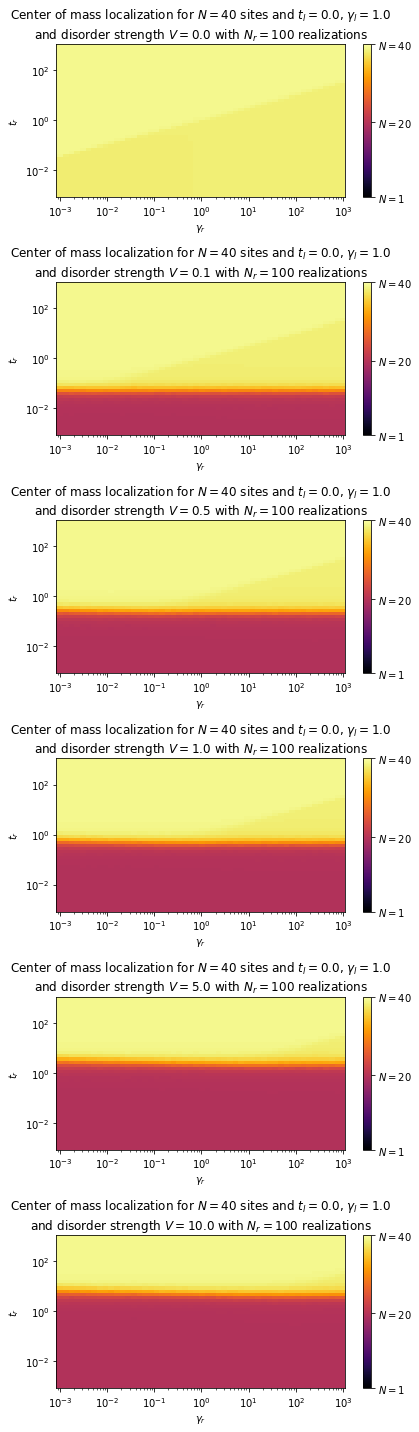

In [40]:
N = 40
tl = 0.0
tr_array = 10**(np.linspace(-3,3,50))
gam_l = 1.0
gam_r_array = 10**(np.linspace(-3,3,51))
rl = 0.0
rr = 0.0
V_array = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]
N_realizations = 10

com_array = np.zeros(shape=(len(tr_array), len(gam_r_array), len(V_array)))
for idx_V, V in enumerate(V_array):
    for idx_tr, tr in enumerate(tr_array):
        for idx_gam_r, gam_r in enumerate(gam_r_array):
            realiz_avg = 0
            for realiz in range(N_realizations):
                onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
                Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                                     V_pot = onsite_pot,
                                                     tl = tl,
                                                     tr = tr,
                                                     gam_l = gam_l,
                                                     gam_r = gam_r,
                                                     rl = rl,
                                                     rr = rr)
                _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
                
                realiz_avg += abs_square_sum_r
        
            realiz_avg /= N_realizations
        
            com = 0
            for idx, i in enumerate(realiz_avg):
                com += i*idx
            com /= np.sum(realiz_avg)        
            com_array[idx_tr, idx_gam_r, idx_V] = com
        
        percentage = (idx_V*len(tr_array) + idx_tr )/(len(V_array)*len(tr_array))*100
        if np.round(percentage,0)%5==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure(figsize=(6,20))
X, Y = np.meshgrid(gam_r_array, tr_array)   


for idx_V, V in enumerate(V_array):
    ax_value = len(V_array)*100 + 10 + idx_V + 1
    ax = fig.add_subplot(ax_value)
    
    heatmap = ax.pcolormesh(X, Y, com_array[:, :, idx_V], vmin = 1, vmax = N, cmap="inferno", shading="auto")
                     
    ax.set_xlabel(r"$\gamma_r$")
    ax.set_ylabel(r"$t_r$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(r"Center of mass localization for $N=$%s sites and $t_l=$%s, $\gamma_l=$%s"%(N, tl, gam_l)+"\n"+r"and disorder strength $V=$%s with $N_r=$%s realizations"%(V, N_realizations))
    cbar = plt.colorbar(heatmap, ticks = [1, N/2, N])
    cbar.ax.set_yticklabels([r"$N = 1$", r"$N = {%s}$"%(int(N/2)), r"$N = {%s}$"%(int(N))])
    
plt.tight_layout()
plt.show()

In [41]:
N = 40
tl = 1.0
tr_array = 10**(np.linspace(-3,3,50))
gam_l = 1.0
gam_r_array = 10**(np.linspace(-3,3,51))
rl = 0.0
rr = 0.0
V_array = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]
N_realizations = 10

com_array = np.zeros(shape=(len(tr_array), len(gam_r_array), len(V_array)))
for idx_V, V in enumerate(V_array):
    for idx_tr, tr in enumerate(tr_array):
        for idx_gam_r, gam_r in enumerate(gam_r_array):
            realiz_avg = 0
            for realiz in range(N_realizations):
                onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
                Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                                     V_pot = onsite_pot,
                                                     tl = tl,
                                                     tr = tr,
                                                     gam_l = gam_l,
                                                     gam_r = gam_r,
                                                     rl = rl,
                                                     rr = rr)
                _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
                
                realiz_avg += abs_square_sum_r
        
            realiz_avg /= N_realizations
        
            com = 0
            for idx, i in enumerate(realiz_avg):
                com += i*idx
            com /= np.sum(realiz_avg)        
            com_array[idx_tr, idx_gam_r, idx_V] = com
        
        percentage = (idx_V*len(tr_array) + idx_tr )/(len(V_array)*len(tr_array))*100
        if np.round(percentage,0)%5==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure(figsize=(6,20))
X, Y = np.meshgrid(gam_r_array, tr_array)   


for idx_V, V in enumerate(V_array):
    ax_value = len(V_array)*100 + 10 + idx_V + 1
    ax = fig.add_subplot(ax_value)
    
    heatmap = ax.pcolormesh(X, Y, com_array[:, :, idx_V], vmin = 1, vmax = N, cmap="inferno", shading="auto")
                     
    ax.set_xlabel(r"$\gamma_r$")
    ax.set_ylabel(r"$t_r$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(r"Center of mass localization for $N=$%s sites and $t_l=$%s, $\gamma_l=$%s"%(N, tl, gam_l)+"\n"+r"and disorder strength $V=$%s with $N_r=$%s realizations"%(V, N_realizations))
    cbar = plt.colorbar(heatmap, ticks = [1, N/2, N])
    cbar.ax.set_yticklabels([r"$N = 1$", r"$N = {%s}$"%(int(N/2)), r"$N = {%s}$"%(int(N))])
    
plt.tight_layout()
plt.show()

0.0% of calculation completed.
0.33333333333333337% of calculation completed.
4.666666666666667% of calculation completed.
5.0% of calculation completed.
5.333333333333334% of calculation completed.


KeyboardInterrupt: 

0.0% of calculation completed.
0.33333333333333337% of calculation completed.
4.666666666666667% of calculation completed.
5.0% of calculation completed.
5.333333333333334% of calculation completed.
9.666666666666666% of calculation completed.
10.0% of calculation completed.
10.333333333333334% of calculation completed.
14.666666666666666% of calculation completed.
15.0% of calculation completed.
15.333333333333332% of calculation completed.
19.666666666666664% of calculation completed.
20.0% of calculation completed.
20.333333333333332% of calculation completed.
24.666666666666668% of calculation completed.
25.0% of calculation completed.
25.333333333333336% of calculation completed.
29.666666666666668% of calculation completed.
30.0% of calculation completed.
30.333333333333336% of calculation completed.
34.66666666666667% of calculation completed.
35.0% of calculation completed.
35.333333333333336% of calculation completed.
39.666666666666664% of calculation completed.
40.0% of calc

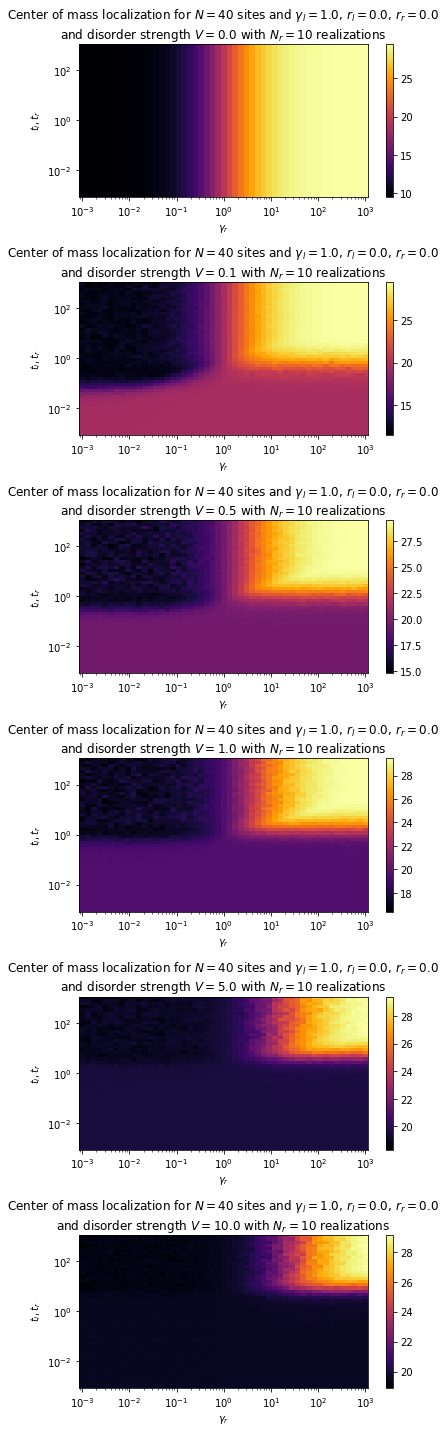

In [45]:
N = 40
tl = 1.0
tr_array = 10**(np.linspace(-3,3,50))
gam_l = 1.0
gam_r_array = 10**(np.linspace(-3,3,51))
rl = 0.0
rr = 0.0
V_array = [0.0, 0.1, 0.5, 1.0, 5.0, 10.0]
N_realizations = 10

com_array = np.zeros(shape=(len(tr_array), len(gam_r_array), len(V_array)))
for idx_V, V in enumerate(V_array):
    for idx_tr, tr in enumerate(tr_array):
        for idx_gam_r, gam_r in enumerate(gam_r_array):
            realiz_avg = 0
            for realiz in range(N_realizations):
                onsite_pot = NHI.random_onsite_pot(N = N, low = -1.0, high = 1.0, V = V)
                Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = N,
                                                     V_pot = onsite_pot,
                                                     tl = tr,
                                                     tr = tr,
                                                     gam_l = gam_l,
                                                     gam_r = gam_r,
                                                     rl = rl,
                                                     rr = rr)
                _, _, _, _, abs_square_sum_r,_ = NHI.extract_spectrum(Ham)
                
                realiz_avg += abs_square_sum_r
        
            realiz_avg /= N_realizations
        
            com = 0
            for idx, i in enumerate(realiz_avg):
                com += i*idx
            com /= np.sum(realiz_avg)        
            com_array[idx_tr, idx_gam_r, idx_V] = com
        
        percentage = (idx_V*len(tr_array) + idx_tr )/(len(V_array)*len(tr_array))*100
        if np.round(percentage,0)%5==0:
            print(f"{percentage}% of calculation completed.")


fig = plt.figure(figsize=(6,20))
X, Y = np.meshgrid(gam_r_array, tr_array)   


for idx_V, V in enumerate(V_array):
    ax_value = len(V_array)*100 + 10 + idx_V + 1
    ax = fig.add_subplot(ax_value)
    
    heatmap = ax.pcolormesh(X, Y, com_array[:, :, idx_V], cmap="inferno", shading="auto")
                     
    ax.set_xlabel(r"$\gamma_r$")
    ax.set_ylabel(r"$t_l, t_r$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(r"Center of mass localization for $N=$%s sites and $\gamma_l=$%s, $r_l=$%s, $r_r=$%s"%(N, gam_l, rl, rr)+"\n"+r"and disorder strength $V=$%s with $N_r=$%s realizations"%(V, N_realizations))
    cbar = plt.colorbar(heatmap)
    
plt.tight_layout()
plt.show()

# Extraction of localization length

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

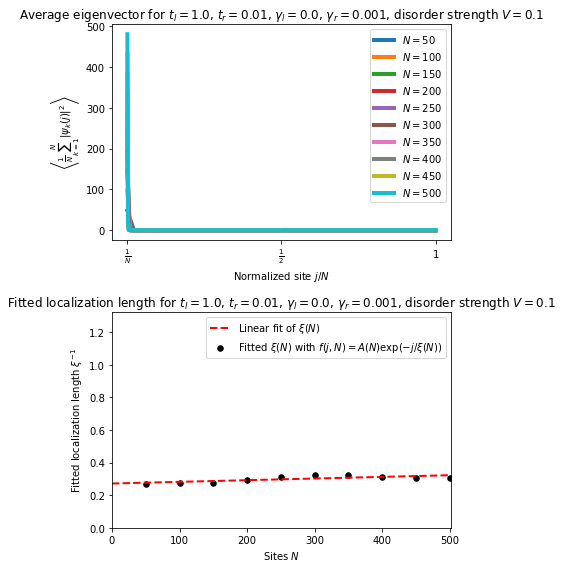

In [12]:
# Define quantities:
#sites_array = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
sites_array = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
tr = 0.01 
tl = 1.0
rl = 0.0
rr = 0.0
gam_l = 0.0
gam_r = 0.001
V = 0.1
N_realizations = 100

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

#ass_list = []
disorder_avg_list = []
for idx, sites in enumerate(sites_array):
    
    ass_list_realiz = []
    # Average over all realizations:
    disorder_avg = 0
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = sites, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = sites,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             rl = rl,
                                             rr = rr,
                                             gam_l = gam_l,
                                             gam_r = gam_r)
        _, _, _, _, abs_square_sum,_ = NHI.extract_spectrum(Ham)
        #ass_list_realiz.append(abs_square_sum)
        disorder_avg += abs_square_sum/N_realizations

        percentage = (idx*N_realizations + realiz)/(N_realizations*len(sites_array))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    #ass_list.append(ass_list_realiz) 
    disorder_avg_list.append(disorder_avg)

#print(disorder_avg_list[1])
# Plot of disorder averages:
fig = plt.figure(figsize=(6,8))
ax1 = fig.add_subplot(211)
for idx, sites in enumerate(sites_array):
    site_array = np.linspace(0.0, 1.0, sites) 
    if idx>=0:
        ax1.plot(np.array(site_array), disorder_avg_list[idx], lw=4, label=r"$N=$%s"%(sites))
ax1.set_xlabel(r"Normalized site $j/N$")
ax1.set_xticks([0.0, 0.5, 1.0])
ax1.set_xticklabels([r"$\frac{1}{N}$", r"$\frac{1}{2}$", r"$1$"])
ax1.set_ylabel(r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
ax1.set_title(r"Average eigenvector for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best') #, ncols=2)

def exp_fit(x, A, xi):
    return A*np.exp(-x/xi)

# Exponential fit of each curve as a function of N:
popt_list = []
for idx, sites in enumerate(sites_array):
    if idx>=0:
        x = np.linspace(1.0, sites, sites)
        y = disorder_avg_list[idx]
    
        # fit curve
        popt, _ = curve_fit(f=exp_fit, 
                        xdata=x, 
                        ydata=y)
        popt_list.append(popt)
        #print(f"popts are {popt}")

popt_list = np.array(popt_list)
#print(f"popt_list: {popt_list}")

# linear fit of the fitted xis:
#x = sites_array[1:]
x = sites_array
y = popt_list[:,1]
p = np.polyfit(x, y, 1)
xx = np.linspace(0, sites_array[-1]+2, 1000)
yy = np.polyval(p, xx)

#data = {"disorder_avg_list": disorder_avg_list, 
#        "fit": popt_list,
#        "polyval": yy}
#np.save("fit_hermitian_hopping.npy", data)

# Plot of the fits:
ax2 = fig.add_subplot(212)
ax2.scatter(x, y, label=r"Fitted $\xi(N)$ with $f(j,N) = A(N) \exp(-j/\xi(N))$", s=30, color="black")
ax2.plot(xx, yy, label=r"Linear fit of $\xi(N)$", lw=2, linestyle="dashed", color="red")
ax2.set_xlabel(r"Sites $N$")
ax2.set_ylabel(r"Fitted localization length $\xi^{-1}$")
ax2.set_ylim([0.0, np.amax(popt_list[:,1])+1.0])
ax2.set_xlim([0.0,sites_array[-1]+2])
ax2.set_title(r"Fitted localization length for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best')

plt.tight_layout()
plt.show()

# \xi_R

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

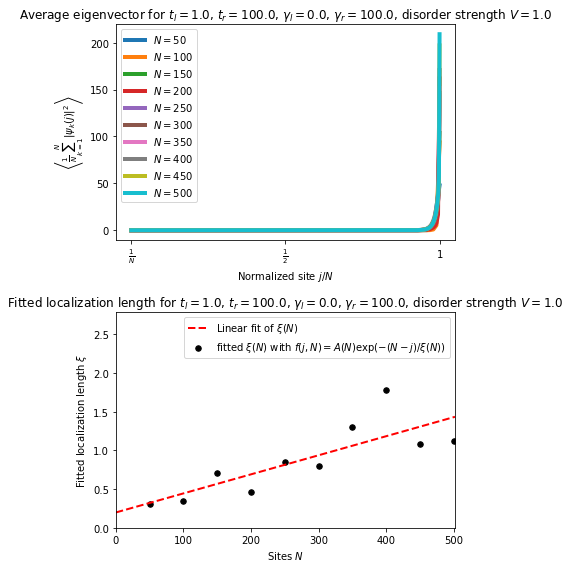

In [23]:
# Define quantities:
#sites_array = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
sites_array = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

tr = 100.0 
tl = 1.0
gam_l = 0.0
gam_r = 100.0
V = 1.0
N_realizations = 100

colors = plt.cm.rainbow(np.linspace(0,1,N_realizations))

#ass_list = []
disorder_avg_list = []
for idx, sites in enumerate(sites_array):
    
    ass_list_realiz = []
    # Average over all realizations:
    disorder_avg = 0
    for realiz in range(N_realizations):
        onsite_pot = NHI.random_onsite_pot(N = sites, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = sites,
                                             V_pot = onsite_pot,
                                             tl = tl,
                                             tr = tr,
                                             rl = rl,
                                             rr = rr,
                                             gam_l = gam_l,
                                             gam_r = gam_r)
        _, _, _, _, abs_square_sum,_ = NHI.extract_spectrum(Ham)
        #ass_list_realiz.append(abs_square_sum)
        disorder_avg += abs_square_sum/N_realizations

        percentage = (idx*N_realizations + realiz)/(N_realizations*len(sites_array))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    #ass_list.append(ass_list_realiz) 
    disorder_avg_list.append(disorder_avg)
    
# Plot of disorder averages:
fig = plt.figure(figsize=(6,8))
ax1 = fig.add_subplot(211)
for idx, sites in enumerate(sites_array):
    site_array = np.linspace(0.0, 1.0, sites) 
    ax1.plot(site_array, disorder_avg_list[idx], lw=4, label=r"$N=$%s"%(sites))
ax1.set_xlabel(r"Normalized site $j/N$")
ax1.set_xticks([0.0, 0.5, 1.0])
ax1.set_xticklabels([r"$\frac{1}{N}$", r"$\frac{1}{2}$", r"$1$"])
ax1.set_ylabel(r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
ax1.set_title(r"Average eigenvector for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best')#, ncols=3)

def exp_fit(x, A, xi):
    return A*np.exp(-(sites-x)/xi)

# Exponential fit of each curve as a function of N:
popt_list = []
for idx, sites in enumerate(sites_array):
    x = np.linspace(1.0, sites, sites) 
    y = disorder_avg_list[idx]
    
    # fit curve
    popt, _ = curve_fit(f=exp_fit, 
                        xdata=x, 
                        ydata=y)
    popt_list.append(popt)
    #print(f"popts are {popt}")

popt_list = np.array(popt_list)
#print(f"popt_list: {popt_list}")

# linear fit of the fitted xis:
x = sites_array
y = popt_list[:,1]
p = np.polyfit(x, popt_list[:,1], 1)
xx = np.linspace(0, sites_array[-1]+2, 1000)
yy = np.polyval(p, xx)

# Plot of the fits:
ax2 = fig.add_subplot(212)
ax2.scatter(x, y, label=r"fitted $\xi(N)$ with $f(j,N) = A(N) \exp(-(N-j)/\xi(N))$", s=30, color="black")
ax2.plot(xx, yy, label=r"Linear fit of $\xi(N)$", lw=2, linestyle="dashed", color="red")
ax2.set_xlabel(r"Sites $N$")
ax2.set_ylabel(r"Fitted localization length $\xi$")
ax2.set_ylim([0.0, np.amax(popt_list[:,1])+1.0])
ax2.set_xlim([0.0,sites_array[-1]+2])
ax2.set_title(r"Fitted localization length for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best')

plt.tight_layout()
plt.show()

0.0% of program complete.
2.0% of program complete.
4.0% of program complete.
6.0% of program complete.
8.0% of program complete.
10.0% of program complete.
12.0% of program complete.
16.0% of program complete.
18.0% of program complete.
20.0% of program complete.
22.0% of program complete.
24.0% of program complete.
26.0% of program complete.
30.0% of program complete.
32.0% of program complete.
34.0% of program complete.
36.0% of program complete.
38.0% of program complete.
40.0% of program complete.
42.0% of program complete.
44.0% of program complete.
46.0% of program complete.
48.0% of program complete.
50.0% of program complete.
52.0% of program complete.
54.0% of program complete.
60.0% of program complete.
62.0% of program complete.
64.0% of program complete.
66.0% of program complete.
68.0% of program complete.
70.0% of program complete.
72.0% of program complete.
74.0% of program complete.
76.0% of program complete.
78.0% of program complete.
80.0% of program complete.
82.0% 

C:\Users\suzib\AppData\Local\Temp/ipykernel_18860/1135996901.py:105: RuntimeWarning: overflow encountered in exp
  return A*np.exp(-(sites-x)/xi)


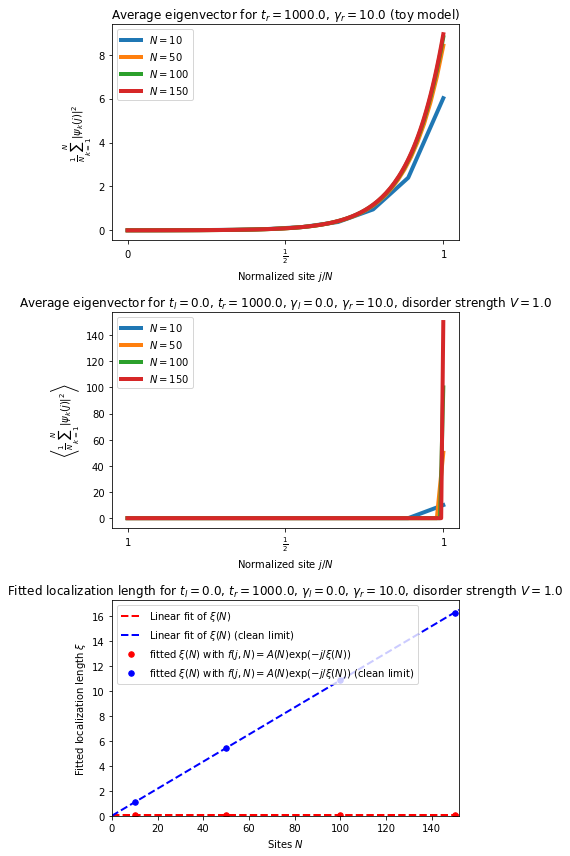

In [29]:
## Linear fittings xi

tl = 0.0
tr = 1000.0
gam_r = 10.0
gam_l = 0.0
rl = 0.0
rr = 0.0

sites_array = [50, 100, 200, 300, 400, 500]
#sites_array = [10, 20, 30, 40, 50]
N_realization = 1000
V = 0.1

# TOY MODEL
############################################################################
Revecs_list_tm = []
ass_list_tm = []
for N_idx, N in enumerate(sites_array):
    exact_evals = np.zeros(N, dtype=np.complex_)
    exact_Revecs = np.zeros(shape=(N,N), dtype=np.complex_)
    for n in range(N):
        exact_evals[n] = np.exp(2*np.pi*1j*n)*gam_r**(1/N)*tr**((N-1)/N)
        
        for l in range(N):
            exact_Revecs[l,n] = np.exp(-2*np.pi*1j*n*l/N)*(gam_r/tr)**((N-l)/N)
            
        # Normalization to 1:
        #print(exact_Revecs[:,n])
        exact_Revecs[:,n] /= spla.norm(exact_Revecs[:,n])
        #print(exact_Revecs[:,n])
        #print(f"norm: {spla.norm(exact_Revecs[:,n])}")
        #print("\n")
        
    Revecs_list_tm.append(exact_Revecs)
    
    # Sum of all eigenvectors (their absolute square):
    abs_square_sum_tm = 0
    for n in range(N):
        abs_square_sum_tm += np.abs(exact_Revecs[:,n])**2
    
    ass_list_tm.append(abs_square_sum_tm)
############################################################################


# Disordered case
############################################################################
disorder_avg_list = []
for idx, sites in enumerate(sites_array):
    
    ass_list_realiz = []
    # Average over all realizations:
    disorder_avg = np.zeros(sites)
    for realiz in range(N_realization):
        onsite_pot = NHI.random_onsite_pot(N = sites, low = -1.0, high = 1.0, V = V)
        Ham = NHI.Hatano_Nelson_plus_pot_Ham(N = sites,
                                              V_pot = onsite_pot,
                                              tl = tl,
                                              tr = tr,
                                              rl = rl,
                                              rr = rr,
                                              gam_l = gam_l,
                                              gam_r = gam_r)
        _, _, _, _, abs_square_sum, _ = NHI.extract_spectrum(Ham)
        
        #ass_list_realiz.append(abs_square_sum)
        disorder_avg += abs_square_sum/N_realization

        percentage = (idx*N_realization + realiz)/(N_realization*len(sites_array))*100
        if 10*percentage%20==0:
            print(f"{percentage}% of program complete.")
    
    #ass_list.append(ass_list_realiz) 
    disorder_avg_list.append(disorder_avg)
############################################################################



# Plots
fig = plt.figure(figsize=(6,12))
ax1 = fig.add_subplot(311)
for idx, sites in enumerate(sites_array):
    site_array = np.linspace(0.0, 1.0, sites) 
    ax1.plot(site_array, ass_list_tm[idx], lw=4, label=r"$N=$%s"%(sites))
ax1.set_xlabel(r"Normalized site $j/N$")
ax1.set_xticks([0.0, 0.5, 1.0])
ax1.set_xticklabels([r"$\frac{1}{N}$", r"$\frac{1}{2}$", r"$1$"])
ax1.set_ylabel(r"$\frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2$")
ax1.set_title(r"Average eigenvector for $t_r=$%s, $\gamma_r=$%s (toy model)"%(tr, gam_r))
plt.legend(loc='best')#, ncols=3)


# Plot of disorder averages:
ax2 = fig.add_subplot(312)
for idx, sites in enumerate(sites_array):
    site_array = np.linspace(0.0, 1.0, sites) 
    ax2.plot(site_array, disorder_avg_list[idx], lw=4, label=r"$N=$%s"%(sites))
ax2.set_xlabel(r"Normalized site $j/N$")
ax2.set_xticks([0.0, 0.5, 1.0])
ax2.set_xticklabels([r"$\frac{1}{N}$", r"$\frac{1}{2}$", r"$1$"])
ax2.set_ylabel(r"$\left< \frac{1}{N} \sum_{k=1}^N |\psi_k(j)|^2 \right>$")
ax2.set_title(r"Average eigenvector for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best')#, ncols=3)



def exp_fit_right(x, A, xi):
    return A*np.exp(-(sites-x)/xi)

def exp_fit_left(x, A, xi):
    return A*np.exp(-x/xi)

# Exponential fit of each curve as a function of N:
popt_list_tm = []
popt_list_disorder = []

for idx, sites in enumerate(sites_array):
    x = np.linspace(1.0, sites, sites) 
    y_tm = ass_list_tm[idx]
    y_disorder = disorder_avg_list[idx]
    
    # fit curve
    popt_tm, _ = curve_fit(f = exp_fit_left, xdata = x, ydata = y_tm)
    popt_list_tm.append(popt_tm)
    
    popt_disorder, _ = curve_fit(f=exp_fit_left, xdata=x, ydata=y_disorder)
    
    popt_list_disorder.append(popt_disorder)
    
    #print(f"popts are {popt}")

popt_list_tm = np.array(popt_list_tm)
popt_list_disorder = np.array(popt_list_disorder)

#print(f"popt_list_tm: {popt_list_tm}")
#print(f"popt_list_disorder: {popt_list_disorder}")


# linear fit of the fitted xis:
x = sites_array
xi_tm = popt_list_tm[:,1]
xi_disorder = popt_list_disorder[:,1]

p_tm = np.polyfit(x, popt_list_tm[:,1], 1)
p_disorder = np.polyfit(x, popt_list_disorder[:,1], 1)

xx = np.linspace(0, sites_array[-1]+2, 1000)
yy_tm = np.polyval(p_tm, xx)
yy_disorder = np.polyval(p_disorder, xx)



# Plot of the fits:
ax3 = fig.add_subplot(313)
ax3.scatter(x, xi_disorder, label=r"fitted $\xi(N)$ with $f(j,N) = A(N) \exp(-j/\xi(N))$", s=30, color="red")
ax3.plot(xx, yy_disorder, label=r"Linear fit of $\xi(N)$", lw=2, linestyle="dashed", color="red")

ax3.scatter(x, xi_tm, label=r"fitted $\xi(N)$ with $f(j,N) = A(N) \exp(-j/\xi(N))$ (clean limit)", s=30, color="blue")
ax3.plot(xx, yy_tm, label=r"Linear fit of $\xi(N)$ (clean limit)", lw=2, linestyle="dashed", color="blue")

ax3.set_xlabel(r"Sites $N$")
ax3.set_ylabel(r"Fitted localization length $\xi$")
ax3.set_ylim([0.0, np.amax(popt_list_tm[:,1])+1.0])
ax3.set_xlim([0.0,sites_array[-1]+2])
ax3.set_title(r"Fitted localization length for $t_l=$%s, $t_r=$%s, $\gamma_l=$%s, $\gamma_r=$%s, disorder strength $V=$%s"%(tl, tr, gam_l, gam_r, V))
plt.legend(loc='best')

plt.tight_layout()
plt.show()